<a href="https://colab.research.google.com/github/HNXJ/GSDR/blob/main/GSDR_SX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resembling high-density electrophysiology

Spectral power tuning in Hodgkin-Huxley based biophysical neuronal network

 Part of the supplements of *"A genetic algorithm for self-supervised models of oscillatory neurodynamics (2025, under-review)"*


## Description

In these simulations, Hodgkin-Huxley based biophysical networks are trained to maximize the coherence bewteen the model's power spectrum density (PSD) and  in-vivo recorded single neurons PSD.

Network consists of 50 neurons (36 excitatory, 14 inhibitory) with uniform synaptic time constants and initial synaptic conductances. Connectivity pattern of all neurons except 7 (half) of inhibitory neurons which are restricted to have 10 or less connections as a presynaptic neuros (This is explained in the results section, to resemble local PV-like interneurons)

Objective is to replicate a stimulus dependent push-pull (Bastos et. al, 2020) between lower frequency alpha/beta (~ 8-30Hz) and gamma (~32Hz+) bands. More specifically, this push-pull is observed in single neurons recorded with dense laminar neurophysiology data in non-human primates (macaque) visual cortex area(s) MT/MST during active visual presentation of a moving grating (Westerberg et. al, 2024). In addition, the stimulus evoked gamma is relatively narrow band (37.5Hz +- 2Hz).

## Setup

### Packages

In [2]:
%pip install jaxley

import os
os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=24'

from jax import config
config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu") # 'gpu' / 'cpu'
# config.update("jax_debug_nans", True)

import jax
import numpy as np
import jaxley as jx
import jax.numpy as jnp
import matplotlib.pyplot as plt
import jaxley.optimize.transforms as jt

from jax import jit, vmap, value_and_grad
from jaxley.channels import Leak, HH
from jaxley.synapses import IonotropicSynapse
from jaxley.connect import fully_connect, sparse_connect, connect
from scipy import ndimage
import scipy
import pickle


figure_save_path = "/content/data/Figures"
model_save_path = "/content/data/NeuralCircuits"
save_dir = "/content/data/SignalArrays/"

# from google.colab import drive
# drive.mount('/content/drive/')
# figure_save_path = "/content/drive/MyDrive/Workspace/Figures" # Drive
# model_save_path = "/content/drive/MyDrive/Workspace/Models" # Drive
# save_dir = "/content/drive/MyDrive/Workspace/" # Drive


file_name = "selected_unit_spiking.npy"

save_path = os.path.join(save_dir, file_name)
selected_unit_spiking = jnp.load(save_path)
print(f"'selected_unit_spiking' loaded from {save_path}")
print(f"Shape of loaded_selected_unit_spiking: {selected_unit_spiking.shape}")

'selected_unit_spiking' loaded from /content/data/SignalArrays/selected_unit_spiking.npy
Shape of loaded_selected_unit_spiking: (40, 2000, 95)


### Functions

In [3]:
import jax.numpy as jnp
import jaxley as jx
import numpy as np
import jaxley.optimize.transforms as jt

from jax import jit, vmap, value_and_grad
from jaxley.channels import Leak, HH, Channel
from jaxley.synapses import IonotropicSynapse, Synapse
from jaxley.connect import fully_connect, sparse_connect, connect

import jax.numpy as jnp
import matplotlib.pyplot as plt
import jaxley.optimize.transforms as jt

from jax import jit, vmap, value_and_grad
from jaxley.channels import Leak, HH
from jaxley.synapses import IonotropicSynapse
from jaxley.connect import fully_connect, sparse_connect, connect

from matplotlib.colors import ListedColormap # Import for custom colormap
from scipy import signal # Import scipy.signal for spectrogram
from scipy import ndimage # Import scipy.ndimage for smoothing

import optax
from flax.struct import dataclass # For GSDR
from typing import Any, Callable, NamedTuple, Optional # For GSDR


def save_jnn(filename, filepath, net_object, initial_params, mid_params, final_params, log_net):
    """
    Saves various components of the JAXley model to a single .pkl file using pickle.
    Args:
        filename (str): Base name for the file (e.g., "model_001").
        filepath (str): Directory path to save the file.
        net_object (jx.Network): The JAXley network object.
        initial_params: Initial parameters of the network.
        mid_params: Intermediate parameters (if any).
        final_params: Final trained parameters of the network.
        log_net: Training log data.
    """
    full_path = os.path.join(filepath, filename + ".pkl") # Changed extension to .pkl

    # Collect all data into a dictionary
    model_data = {
        'initial_params': initial_params,
        'mid_params': mid_params,
        'final_params': final_params,
        'log_net': log_net,
        'net_params': net_object.get_parameters(), # Save the current parameters of the net
        'Ne': Ne, # Using global Ne variable
        'Nig': Nig, # Using global Nig variable
        'Nil': Nil, # Using global Nil variable
    }

    with open(full_path, "wb") as handle:
        pickle.dump(model_data, handle) # Use pickle.dump directly
    print(f"Model components saved to {full_path}")


def load_jnn(filename, filepath):
    """
    Loads various components of the JAXley model from a .pkl file using pickle.
    Args:
        filename (str): Base name for the file (e.g., "model_001").
        filepath (str): Directory path to load the file from.
    Returns:
        tuple: (rebuilt_net_object, initial_params, mid_params, final_params, log_net)
              where rebuilt_net_object is recreated and its parameters set.
    """
    full_path = os.path.join(filepath, filename) # .pkl
    with open(full_path, "rb") as handle:
        loaded_data = pickle.load(handle) # Use pickle.load directly

    initial_params = loaded_data['initial_params']
    mid_params = loaded_data['mid_params']
    final_params = loaded_data['final_params']
    log_net = loaded_data['log_net']
    net_params = loaded_data['net_params']

    rebuilt_net = net_eig(loaded_data['Ne'], loaded_data['Nig'], loaded_data['Nil'])
    print(f"Model components loaded from {full_path}")
    return rebuilt_net, initial_params, mid_params, final_params, log_net


def plot_voltages_as_image(recorded_voltages, time_axis, title="Recorded Voltages as Image", cmap='jet'):
    """
    Plots recorded voltages as a 2D image.

    Args:
        recorded_voltages (jnp.ndarray): Array of shape (num_neurons, num_timepoints).
        time_axis (jnp.ndarray): Array of time points.
        title (str): Title for the plot.
        cmap (str): Colormap to use for the image (default: 'jet').
    """
    plt.figure(figsize=(12, 5))
    # Transpose recorded_voltages to have time on x-axis and neuron index on y-axis
    # Using only the voltage data (excluding the first 'time' column if present in recorded_voltages)
    # If recorded_voltages has shape (num_neurons, num_timepoints + 1) where first col is time,
    # then use recorded_voltages[:, 1:].T
    # Given recorded_voltages.shape is (10, 40001) and time_axis.shape is (40000,),
    # it seems the first element of recorded_voltages for each neuron is V_init or similar,
    # and the time_axis correctly corresponds to the subsequent 40000 points.
    # So we plot recorded_voltages[:, 1:].
    plt.imshow(
        recorded_voltages[:, 1:],
        aspect='auto',
        cmap=cmap,
        origin='lower',
        extent=[time_axis[0], time_axis[-1], 0, recorded_voltages.shape[0]]
    )
    plt.colorbar(label='Voltage (mV)')
    plt.title(title)
    plt.xlabel('Time (ms)')
    plt.ylabel('Neuron Index')
    plt.show()

def plot_raster(recorded_voltages, time_axis, spike_threshold=-20.0, title='Raster Plot (Spikes > -20mV)'):
    """
    Plots a raster of detected spikes from recorded voltages.

    Args:
        recorded_voltages (jnp.ndarray): Array of time points.
        time_axis (jnp.ndarray): Array of time points.
        spike_threshold (float):
        title (str): Title for the plot.
    """
    spike_times_list = []
    num_neurons = recorded_voltages.shape[0]

    for i in range(num_neurons):
        # Extract voltage trace for the current neuron, aligning with time_axis
        neuron_trace = recorded_voltages[i, 1:]

        # Detect spikes: voltage crosses threshold from below
        spikes = (neuron_trace[:-1] < spike_threshold) & (neuron_trace[1:] >= spike_threshold)
        spike_indices = jnp.where(spikes)[0]
        spike_times = time_axis[spike_indices]
        spike_times_list.append(spike_times)

    plt.figure(figsize=(12, 5))
    plt.eventplot(spike_times_list, lineoffsets=jnp.arange(num_neurons), linelengths=0.8, color='black')
    plt.title(title)
    plt.xlabel('Time (ms)')
    plt.ylabel('Neuron Index')
    plt.yticks(jnp.arange(num_neurons))
    plt.ylim(-0.5, num_neurons - 0.5)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_time_frequency_response(recorded_voltages, time_axis, dt_global,
                                 window_size=100.0, overlap=0.9,
                                 f_min=0.5, f_max=100.0, title='Time-Frequency Response (Mean Voltage)', cmap='jet', log_y_scale: bool = False):
    """
    Plots the time-frequency power spectrum (spectrogram) of the mean neuronal potential.

    Args:
        recorded_voltages (jnp.ndarray): Array of shape (num_neurons, num_timepoints).
        time_axis (jnp.ndarray): Array of time points.
        dt_global (float): Global time step in ms.
        window_size (float): Size of the FFT window in ms (default: 100ms).
        overlap (float): Overlap between windows as a fraction (default: 0.9).
        f_min (float): Minimum frequency to display in Hz (default: 0.5Hz).
        f_max (float): Maximum frequency to display in Hz (default: 100Hz).
        title (str): Title for the plot.
        cmap (str): Colormap to use for the spectrogram (default: 'jet').
        log_y_scale (bool): Whether to use a logarithmic scale for the y-axis (frequency) (default: False).
    """
    # 1. Compute the mean neuronal potential signal
    # Exclude the initial voltage value (V_init) at recorded_voltages[:, 0]
    mean_signal = jnp.mean(recorded_voltages[:, 1:], axis=0)

    # Convert JAX numpy array to numpy array for scipy compatibility
    mean_signal_np = np.asarray(mean_signal)
    mean_signal_np = mean_signal_np.astype(np.float64)

    # Smooth the mean_signal_np with a moving mean window of length 10ms
    smoothing_window_samples = int(2.0 / dt_global) # 10ms / 0.1ms = 100 samples
    if smoothing_window_samples > 1:
        mean_signal_np = ndimage.uniform_filter1d(mean_signal_np, size=smoothing_window_samples)

    # 2. Calculate sampling frequency (Hz)
    fs = 1000.0 / dt_global # dt_global is in ms, fs in Hz

    # 3. Spectrogram parameters
    nperseg = int(window_size * fs / 1000.0) # Convert window_size (ms) to samples
    if nperseg == 0: nperseg = 1 # Ensure nperseg is at least 1
    noverlap = int(nperseg * overlap)

    # Ensure noverlap is less than nperseg
    if noverlap >= nperseg:
        noverlap = nperseg - 1
    if noverlap < 0:
        noverlap = 0

    # 4. Compute spectrogram
    frequencies, times, Sxx = signal.spectrogram(mean_signal_np, fs=fs,
                                                 window='hann', nperseg=nperseg,
                                                 noverlap=noverlap)

    # 5. Filter frequencies
    freq_indices = (frequencies >= f_min) & (frequencies <= f_max)
    frequencies_filtered = frequencies[freq_indices]
    Sxx_filtered = Sxx[freq_indices, :]

    # Handle case where no frequencies are in the specified range
    if frequencies_filtered.size == 0:
        print("Warning: No frequencies found within the specified f_min and f_max range.")
        plt.show()
        return

    # Convert to dB scale
    Sxx_log = Sxx_filtered#10 * jnp.log10(Sxx_filtered)

    # Scale Sxx_log to [0, 1]
    min_val = jnp.min(Sxx_log)
    max_val = jnp.max(Sxx_log)
    # Avoid division by zero if all values are identical
    if (max_val - min_val) == 0:
        Sxx_scaled = jnp.zeros_like(Sxx_log)
    else:
        Sxx_scaled = np.sqrt((Sxx_log - min_val) / (max_val - min_val))

    # 6. Plotting
    plt.figure(figsize=(14, 6))
    plt.pcolormesh(times * 1000, frequencies_filtered, Sxx_scaled,
                   cmap=cmap, shading='gouraud')
    plt.colorbar(label='Normalized Power (0-1)') # Label updated to reflect scaling
    plt.title(title)
    plt.xlabel('Time (ms)') # Changed to ms
    plt.ylabel('Frequency (Hz)')

    if log_y_scale:
        plt.yscale('log') # Set y-axis to logarithmic scale

    # New red dashed line values
    red_line_freqs = [3.0, 8.0, 12.0, 20.0, 30.0, 70.0]

    # Combine user-specified base log ticks with red line frequencies and f_max/f_min candidates
    log_ticks_candidate = [1, 3, 10, 30, 100] # User's requested base ticks
    log_ticks_candidate.extend(red_line_freqs)
    log_ticks_candidate.append(f_max)
    log_ticks_candidate.append(f_min) # Ensure f_min is also a candidate for a tick

    # Remove duplicates and sort
    log_ticks = sorted(list(set(log_ticks_candidate)))

    # Filter ticks to be strictly within the actual plotted frequency range
    min_actual_freq = frequencies_filtered[0]
    max_actual_freq = frequencies_filtered[-1]

    if log_y_scale: # Only apply custom log ticks if log_y_scale is true
        log_ticks = [t for t in log_ticks if min_actual_freq <= t <= max_actual_freq]

        # Create tick labels and determine their colors
        tick_labels = []
        tick_label_colors = []
        for t in log_ticks:
            label = str(int(t)) if t >= 1 else f'{t:.1f}'
            tick_labels.append(label)
            if t in red_line_freqs:
                tick_label_colors.append('red')
            else:
                tick_label_colors.append('black')

        ax = plt.gca() # Get current axes
        ax.set_yticks(log_ticks)
        ax.set_yticklabels(tick_labels)

        for i, label in enumerate(ax.get_yticklabels()):
            label.set_color(tick_label_colors[i])

    # Set y-limits to the actual range of filtered frequencies to avoid white space
    plt.ylim([min_actual_freq, max_actual_freq])

    # Add red dashed y-lines for specific frequencies
    # These lines should also respect the *actual plotted* range
    for freq_line in red_line_freqs:
        if min_actual_freq <= freq_line <= max_actual_freq:
            plt.axhline(y=freq_line, color='red', linestyle='--', linewidth=1.5)

    plt.tight_layout()
    plt.show()


class GradedGABAa(Synapse):
    """
    Graded fast Inhibitory Synapse. (GABAa)
    Ref: Golowasch et al. (1999) ; Prinz, A. A., et al. (2004).
    """
    def __init__(self, tauD_GABAa: Optional[float] = None):
        super().__init__()

        r_d_gSyn = np.random.uniform(2.5, 7.5)

        self.synapse_params = {
            "gGABAa": r_d_gSyn,       # Reduced initial conductance
            "EGABAa": -80.0,     # Reversal Potential (mV)
            "tauDGABAa": 5.0,        # Decay (ms)
            "tauRGABAa": 0.5,         # Rise (ms)
            "slopeGABAa": 5.0,        # Steepness of activation
            "V_thGABAa": -20.0        # Threshold (mV) - Tuned to activate during spikes
        }

        if tauD_GABAa is not None:
            self.synapse_params["tauDGABAa"] = tauD_GABAa

        self.synapse_states = {"sGABAa": 0.01}

    def update_states(self, states, dt, pre_v, post_v, params):
        # s' = -s/tauD + 0.5*(1+tanh((V-Vth)/slope)) * ((1-s)/tauR)
        s = states["sGABAa"]
        activation = 0.5 * (1 + jnp.tanh((pre_v - params["V_thGABAa"]) / params["slopeGABAa"]))
        d_s = (-s / params["tauDGABAa"]) + activation * ((1 - s) / params["tauRGABAa"])
        return {"sGABAa": s + d_s * dt}

    def compute_current(self, states, pre_v, post_v, params):
        return params["gGABAa"] * states["sGABAa"] * (post_v - params["EGABAa"])


class GradedGABab(Synapse):
    """
    Graded slow Inhibitory Synapse. (GABab)
    Ref: Golowasch et al. (1999) ; Prinz, A. A., et al. (2004).
    """
    def __init__(self, tauD_GABab: Optional[float] = None):
        super().__init__()
        r_d_gSyn = np.random.uniform(2.5, 7.5)
        self.synapse_params = {
            "gGABab": r_d_gSyn,       # Conductance (uS)
            "EGABab": -95.0,     # Reversal Potential (mV)
            "tauDGABab": 200.0,        # Decay (ms)
            "tauRGABab": 10.0,         # Rise (ms)
            "slopeGABab": 5.0,        # Steepness of activation
            "V_thGABab": -20.0        # Threshold (mV) - Tuned to activate during spikes
        }

        if tauD_GABab is not None:
            self.synapse_params["tauDGABab"] = tauD_GABab

        self.synapse_states = {"sGABab": 0.001}

    def update_states(self, states, dt, pre_v, post_v, params):
        # s' = -s/tauD + 0.5*(1+tanh((V-Vth)/slope)) * ((1-s)/tauR)
        s = states["sGABab"]
        activation = 0.5 * (1 + jnp.tanh((pre_v - params["V_thGABab"]) / params["slopeGABab"]))
        d_s = (-s / params["tauDGABab"]) + activation * ((1 - s) / params["tauRGABab"])
        return {"sGABab": s + d_s * dt}

    def compute_current(self, states, pre_v, post_v, params):
        return params["gGABab"] * states["sGABab"] * (post_v - params["EGABab"])


class GradedAMPA(Synapse):
    """
    Graded Excitatory Synapse.
    Same dynamics as GradedGABAa, but with E_rev = 0 mV and faster kinetics
    """
    def __init__(self, tauD_AMPA: Optional[float] = None):
        super().__init__()
        r_d_gSyn = np.random.uniform(1.0, 3.0)
        self.synapse_params = {
            "gAMPA": r_d_gSyn,       # Reduced initial conductance
            "EAMPA": 0.0,        # Reversal Potential (mV) - EXCITATORY
            "tauDAMPA": 5.0,         # Faster decay for AMPA
            "tauRAMPA": 0.2,         # Fast rise
            "slopeAMPA": 5.0,
            "V_thAMPA": -20.0        # Threshold (mV)
        }

        if tauD_AMPA is not None:
            self.synapse_params["tauDAMPA"] = tauD_AMPA

        self.synapse_states = {"sAMPA": 0.01}

    def update_states(self, states, dt, pre_v, post_v, params):
        s = states["sAMPA"]
        # Using same naming convention for internal params, mapped to AMPA
        activation = 0.5 * (1 + jnp.tanh((pre_v - params["V_thAMPA"]) / params["slopeAMPA"]))
        d_s = (-s / params["tauDAMPA"]) + activation * ((1 - s) / params["tauRAMPA"])
        return {"sAMPA": s + d_s * dt}

    def compute_current(self, states, pre_v, post_v, params):
        return params["gAMPA"] * states["sAMPA"] * (post_v - params["EAMPA"])


class Inoise(Channel):
    """
    Stochastic Ornstein-Uhlenbeck noise channel.
    """
    def __init__(self, name: str = None, initial_seed: Optional[int] = None, initial_amp_noise: Optional[float] = None, initial_tau: Optional[float] = None, initial_mean: Optional[float] = None):
        self.current_is_in_mA_per_cm2 = True
        super().__init__(name)

        self.channel_params = {
            "amp_noise": 0.01,  # Reduced initial noise amplitude
            "mean": 0.02,        # The baseline current drive [mA/cm^2]
            "tau": 20.0         # Correlation time constant [ms]
        }
        # If no initial_seed is provided, generate a random one using numpy.
        # This ensures each Inoise instance gets a unique starting seed.
        if initial_seed is None:
            self.channel_params["seed"] = float(np.random.randint(0, 2**16 - 1))
        else:
            self.channel_params["seed"] = float(initial_seed)

        if initial_amp_noise is None:
            self.channel_params["amp_noise"] = float(0.01) # Ensure this default is also reduced
        else:
            self.channel_params["amp_noise"] = float(initial_amp_noise)

        if initial_tau is None:
            self.channel_params["tau"] = float(20.0)
        else:
            self.channel_params["tau"] = float(initial_tau)

        if initial_mean is None:
            self.channel_params["mean"] = float(0.02)
        else:
            self.channel_params["mean"] = float(initial_mean)

        self.channel_states = {"n": 0.00, "step": 0.0}
        self.current_name = "i_noise"

    def update_states(self, states, dt, v, params):
        """
        Updates the noise state 'n' using an Ornstein-Uhlenbeck process.
        """
        n = states["n"]
        step = states["step"]

        # 1. RNG Handling
        # When JAXley vmaps the update_states function, params["seed"] will be an array.
        # All other inputs (n, step, v, dt) will also be batched (arrays).
        # We need to vmap the PRNGKey and fold_in calls.

        # Ensure seed is an integer type for PRNGKey
        seeds_int = params["seed"].astype(int)

        # Create base keys (potentially batched)
        if seeds_int.ndim == 0:
            base_key = jax.random.PRNGKey(seeds_int)
        else:
            base_key = jax.vmap(jax.random.PRNGKey)(seeds_int)

        # Fold in step (potentially batched)
        if step.ndim == 0:
            step_key = jax.random.fold_in(base_key, step.astype(int))
        else: # if step is an array
            step_key = jax.vmap(jax.random.fold_in)(base_key, step.astype(int))

        # Generate normal random numbers (potentially batched)
        # A single JAX PRNGKey has shape (2,) and ndim=1.
        # An array of N JAX PRNGKeys has shape (N, 2) and ndim=2.
        if step_key.ndim == 1: # if step_key is a single key
            xi = jax.random.normal(step_key)
        else: # if step_key is an array of keys (ndim 2 for key array)
            xi = jax.vmap(jax.random.normal)(step_key)

        # 2. Physics (Ornstein-Uhlenbeck)
        # dn = -(n - mean)/tau * dt + sigma*sqrt(2/tau)*dW
        mu = params["mean"]
        sigma = params["amp_noise"]
        tau = params["tau"]

        drift = (mu - n) / tau * dt
        diffusion = sigma * jnp.sqrt(2.0 / tau) * xi * jnp.sqrt(dt_global) # FIX: Changed dt to dt_global

        new_n = n + drift + diffusion # FIX: Changed 'n' to 'n_prev'

        # Return new state AND increment step
        return {"n": new_n, "step": step + 1.0}

    def compute_current(self, states, v, params):
        """
        Returns the current.
        Note: We return negative 'n' so that a positive mean acts
        as an excitatory (depolarizing) injection in the cable equation.
        """
        return -states["n"]

    def init_state(self, states, v, params, delta_t):
        """
        Initialize to the mean value.
        This needs to handle batched parameters if JAXley vmaps init_state.
        """
        # If params["mean"] is a scalar, jnp.zeros_like(params["mean"]) is a scalar 0.0.
        # If params["mean"] is an array, jnp.zeros_like(params["mean"]) is an array of 0.0s.
        # This handles both cases correctly.
        return {"n": jnp.zeros_like(params["mean"]) + params["mean"], "step": jnp.zeros_like(params["mean"]) + 0.0}


class Dataset:
    """
    A simple Dataloader which returns batches of the data.

    Instead of using this simple dataloader, you can also just use one from
    PyTorch or Tensorflow. You do not have to understand what is going on here
    to follow this tutorial.
    """

    def __init__(self, inputs: np.ndarray, labels: np.ndarray):
        """
        Initialize the dataloader.

        Args:
            inputs: Array of shape (num_samples, num_dim)
            labels: Array of shape (num_samples,)
        """
        assert len(inputs) == len(labels), "Inputs and labels must have same length"
        self.inputs = inputs
        self.labels = labels
        self.num_samples = len(inputs)
        self._rng_state = None
        self.batch_size = 1

    def shuffle(self, seed=None):
        """
        Shuffle the dataset in-place
        """
        self._rng_state = np.random.get_state()[1][0] if seed is None else seed
        np.random.seed(self._rng_state)
        indices = np.random.permutation(self.num_samples)
        self.inputs = self.inputs[indices]
        self.labels = self.labels[indices]
        return self

    def batch(self, batch_size):
        """
        Create batches of the data.
        """
        self.batch_size = batch_size
        return self

    def __iter__(self):
        """
        Iterate over the dataset.
        """
        self.shuffle(seed=self._rng_state)
        for start in range(0, self.num_samples, self.batch_size):
            end = min(start + self.batch_size, self.num_samples)
            yield self.inputs[start:end], self.labels[start:end]
        self._rng_state += 1


class ClampTransform(jt.Transform):
    def __init__(self, lower_bound, upper_bound):
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound

    def forward(self, x):
        return jnp.nan_to_num(jnp.clip(x, self.lower_bound, self.upper_bound), 0.0)

    def inverse(self, x):
        return x


@dataclass
class GSDRState:
    inner_state: Any
    params_opt: Any
    inner_state_opt: Any
    loss_opt: float
    a: float
    a_opt: float
    lambda_d: float
    step_count: int
    consecutive_unchanged_epochs: int
    last_optimal_change_step: int

def GSDR(
    inner_optimizer: optax.GradientTransformation,
    delta_distribution: Callable = jax.random.normal,
    deselection_threshold: float = 2.0,
    a_init: float = 0.5,
    lambda_d: float = 1.0,
    a_dynamic: bool = True,
    checkpoint_n: int = 10,
    tau_a_growth: float = 10.0,
    mcdp: bool = True
) -> optax.GradientTransformation:
    """
    Optax-compliant implementation of the Genetic-Stochastic Delta Rule.
    """

    def init_fn(params):
        inner_state = inner_optimizer.init(params)
        return GSDRState(
            inner_state=inner_state,
            params_opt=params,
            inner_state_opt=inner_state,
            loss_opt=jnp.inf,
            a=a_init,
            a_opt=a_init,
            lambda_d=lambda_d,
            step_count=0,
            consecutive_unchanged_epochs=0,
            last_optimal_change_step=0
        )

    def update_fn(updates, state, params=None, value=None, key=None, mcdp_factors=None):

        if params is None:
            raise ValueError("GSDR requires 'params' to be passed to update().")
        if value is None:
            raise ValueError("GSDR requires current loss 'value' to be passed to update().")
        if key is None:
            raise ValueError("GSDR requires a random 'key' to be passed to update().")

        grads = updates
        loss = value

        # 1. Update Best-Known State (Optimality Check)
        # We do this first so we have the correct "safe" state to revert to if needed.
        is_new_opt = (loss < state.loss_opt)

        new_params_opt = jax.tree.map(
            lambda cur, opt: jnp.where(is_new_opt, cur, opt),
            params, state.params_opt
        )
        new_loss_opt = jnp.where(is_new_opt, loss, state.loss_opt)
        new_a_opt = jnp.where(is_new_opt, state.a, state.a_opt)
        new_inner_state_opt = jax.tree.map(
            lambda cur, opt: jnp.where(is_new_opt, cur, opt),
            state.inner_state, state.inner_state_opt
        )

        # Track counters based on optimality
        next_consecutive_unchanged_epochs = jnp.where(
            is_new_opt, 0, state.consecutive_unchanged_epochs + 1
        )
        # If new opt found, the last change is NOW.
        step_of_last_optimal_change = jnp.where(
            is_new_opt, state.step_count + 1, state.last_optimal_change_step
        )

        # 2. Check Reset Conditions (Deselection or Checkpoint)
        # Deselection: Loss exploded or is NaN
        is_deselect = ((loss > (new_loss_opt * deselection_threshold)) & (new_loss_opt != jnp.inf)) | (jnp.isnan(loss))

        # Checkpoint: No improvement for N steps
        is_reset_due_to_checkpoint = (state.step_count > 0) & \
                                     (next_consecutive_unchanged_epochs >= checkpoint_n) & \
                                     (new_loss_opt != jnp.inf)

        should_reset = is_deselect | is_reset_due_to_checkpoint

        # 3. Define Branches using jax.lax.cond
        #    Branch A: Reset (Revert to optimal, skip gradients)
        #    Branch B: Normal Update (Compute gradients, noise, step)

        def reset_branch(operand):
            _params, _new_params_opt, _new_inner_state_opt, _current_step = operand

            # Update: Vector difference to force params back to opt
            reset_updates = jax.tree.map(
                lambda opt_p, cur_p: opt_p - cur_p,
                _new_params_opt, _params
            )

            # State: Reset counters, keep optimal variables
            reset_state = GSDRState(
                inner_state=_new_inner_state_opt, # Reset inner optimizer to saved state
                params_opt=_new_params_opt,
                inner_state_opt=_new_inner_state_opt,
                loss_opt=new_loss_opt,
                a=new_a_opt, # Reset 'a' to optimal 'a'
                a_opt=new_a_opt,
                lambda_d=state.lambda_d,
                step_count=_current_step,
                consecutive_unchanged_epochs=0, # Reset counter
                last_optimal_change_step=_current_step # Reset dynamics timer
            )

            # Debug print for reset
            # jax.debug.print("GSDR: Resetting to optimal at step {}", _current_step)

            if is_reset_due_to_checkpoint:
                print(">Deselection(Checkpoint)")
            elif is_deselect:
                print(">Deselection(Divergence)")

            return reset_updates, reset_state

        def normal_branch(operand):
            _params, _new_params_opt, _new_inner_state_opt, _current_step = operand

            # Calculate 'a' dynamics
            time_since_last_change = jnp.maximum(0, _current_step - step_of_last_optimal_change)
            effective_lambda_d = (time_since_last_change**2) * (1.0 - jnp.exp(-(time_since_last_change) / tau_a_growth))

            # Calculate 'a'
            delta_key, a_key, noise_key = jax.random.split(key, 3)

            if a_dynamic:
                delta_a = jax.random.uniform(a_key, minval=-.1, maxval=.1)
                a_candidate = state.a + delta_a
                next_a = jax.numpy.clip(a_candidate, 0.0, 1.0)
            else:
                next_a = state.a

            # x32 stability transform (clip/omitnan)
            boundTransform = ClampTransform(-1.0, 1.0)

            # Inner Optimizer Update
            inner_updates, updated_inner_state = inner_optimizer.update(grads, state.inner_state, _params)
            inner_updates = jax.tree.map(lambda x: boundTransform.forward(x), inner_updates)

            # Debug print for inner_updates
            inner_updates_flat = jax.tree_util.tree_leaves(inner_updates)
            avg_inner_update = jnp.mean(jnp.concatenate([x.flatten() for x in inner_updates_flat])) if inner_updates_flat else jnp.array(0.0)
            std_inner_update = jnp.std(jnp.concatenate([x.flatten() for x in inner_updates_flat])) if inner_updates_flat else jnp.array(0.0)
            jax.debug.print("GSDR: Avg Inner Update: {}, Std Inner Update: {}", avg_inner_update, std_inner_update)

            # Stochastic Noise Update
            # Use jax.tree.leaves/structure/unflatten for noise generation
            param_leaves, treedef = jax.tree.flatten(_params)
            subkeys = jax.random.split(noise_key, len(param_leaves))
            param_keys_tree = jax.tree.unflatten(treedef, subkeys)

            delta_d = jax.tree.map(
                lambda p, k: effective_lambda_d * delta_distribution(k, p.shape),
                _params, param_keys_tree
            )

            # MCDP if enabled
            if mcdp and mcdp_factors is not None:
                # delta = n * p * r
                delta = jax.tree.map(lambda n, p, r: n * p * r, delta_d, _params, mcdp_factors)
            else:
                delta = jax.tree.map(lambda n, p: n * p, delta_d, _params)

            delta = jax.tree.map(lambda x: boundTransform.forward(x), delta)

            # Debug print for delta (noise)
            delta_flat = jax.tree_util.tree_leaves(delta)
            avg_delta = jnp.mean(jnp.concatenate([x.flatten() for x in delta_flat])) if delta_flat else jnp.array(0.0)
            std_delta = jnp.std(jnp.concatenate([x.flatten() for x in delta_flat])) if delta_flat else jnp.array(0.0)
            jax.debug.print("GSDR: Avg Delta (Noise): {}, Std Delta (Noise): {}", avg_delta, std_delta)

            combined_updates = jax.tree.map(
                lambda d, g: next_a * d + (1 - next_a) * g,
                delta, inner_updates
            )

            # Debug print for combined_updates
            combined_updates_flat = jax.tree_util.tree_leaves(combined_updates)
            avg_combined_update = jnp.mean(jnp.concatenate([x.flatten() for x in combined_updates_flat])) if combined_updates_flat else jnp.array(0.0)
            std_combined_update = jnp.std(jnp.concatenate([x.flatten() for x in combined_updates_flat])) if combined_updates_flat else jnp.array(0.0)
            jax.debug.print("GSDR: Avg Combined Update: {}, Std Combined Update: {}", avg_combined_update, std_combined_update)

            new_normal_state = GSDRState(
                inner_state=updated_inner_state,
                params_opt=_new_params_opt,
                inner_state_opt=_new_inner_state_opt,
                loss_opt=new_loss_opt,
                a=next_a,
                a_opt=new_a_opt,
                lambda_d=state.lambda_d,
                step_count=_current_step,
                consecutive_unchanged_epochs=next_consecutive_unchanged_epochs,
                last_optimal_change_step=step_of_last_optimal_change
            )

            return combined_updates, new_normal_state

        # Execute conditional logic
        current_step = state.step_count + 1
        operand = (params, new_params_opt, new_inner_state_opt, current_step)

        final_updates, new_state = jax.lax.cond(
            should_reset,
            reset_branch,
            normal_branch,
            operand
        )

        return final_updates, new_state

    return optax.GradientTransformation(init_fn, update_fn)


def noise_current(i_delay: float, i_dur: float, i_amp: float, delta_t: float, t_max: float, seed: int = 0) -> jnp.ndarray:
    """
    Generates a random noise current pulse using an Ornstein-Uhlenbeck process.

    Args:
        i_delay: Start time of the current pulse in ms.
        i_dur: Duration of the current pulse in ms.
        i_amp: Overall amplitude scaling of the noise pulse (nA).
        delta_t: Time step for the simulation in ms.
        t_max: Total simulation time in ms.
        seed: Random seed for reproducibility (default: 0).

    Returns:
        jnp.ndarray: Array representing the noise current pulse over time, with shape (int(t_max / delta_t) + 1,).R
    """
    # Parameters for the Ornstein-Uhlenbeck noise process
    noise_standard_deviation = 0.1 # Sigma for OU (nA) - a default value
    noise_correlation_tau = 10.0     # Correlation time in ms
    noise_mean = 0.2                 # Mean of the OU process

    key = jax.random.PRNGKey(seed)

    # Calculate number of steps to include initial state (for JAXley compatibility)
    num_steps = int(t_max / delta_t) + 1
    time_axis_array = jnp.arange(0, t_max + delta_t, delta_t)

    def ou_step_fn(n_prev, key_t):
        key_noise, _ = jax.random.split(key_t)
        xi = jax.random.normal(key_noise)

        drift = (noise_mean - n_prev) / noise_correlation_tau * delta_t
        diffusion = noise_standard_deviation * jnp.sqrt(2.0 / noise_correlation_tau) * xi * jnp.sqrt(dt_global) # FIX: Changed dt to dt_global

        new_n = n_prev + drift + diffusion # FIX: Changed 'n' to 'n_prev'

        # Return new state AND increment step
        return new_n, new_n

    initial_state_ou = noise_mean
    # Split keys for num_steps-1 iterations, as initial_state is already handled
    keys_series = jax.random.split(key, num_steps - 1)

    # Run the scan to generate the raw noise trace
    _, full_noise_trace_raw = jax.lax.scan(ou_step_fn, initial_state_ou, keys_series)
    # Prepend the initial state to get the full trace length
    full_noise_trace = jnp.concatenate([jnp.array([initial_state_ou]), full_noise_trace_raw])

    # Apply the pulse window based on i_delay and i_dur
    time_off = i_delay + i_dur
    pulse_mask = (time_axis_array >= i_delay) & (time_axis_array <= time_off)

    # Scale the noise by i_amp and apply the pulse mask
    noise_current_pulse_array = jnp.where(pulse_mask, full_noise_trace * i_amp, 0.0)

    return noise_current_pulse_array


import jax
import jax.numpy as jnp

def noise_current_ac(
    i_delay: float,
    i_dur: float,
    amp_n: float,
    amp_b: float,
    spect: jnp.ndarray,
    delta_t: float,
    t_max: float,
    seed: int = 0
) -> jnp.ndarray:
    """
    Generates a current composed of an Ornstein-Uhlenbeck noise pulse and
    a superposition of sinusoidal waves (AC).

    Formula: I_total = (OU_Noise * amp_n) + (Sum(Sin(spect)) * amp_b)

    Args:
        i_delay: Start time of the pulse window in ms.
        i_dur: Duration of the pulse window in ms.
        amp_n: Amplitude scaling for the OU noise component (nA).
        amp_b: Amplitude scaling for the AC/Sinusoidal component (nA).
        spect: 1D array of frequencies (Hz) to construct the AC signal.
               Example: jnp.array([10.0, 40.0, 100.0]) for 10, 40, and 100Hz.
        delta_t: Time step for the simulation in ms.
        t_max: Total simulation time in ms.
        seed: Random seed for reproducibility.

    Returns:
        jnp.ndarray: The combined current trace (nA).
    """

    num_steps = int(t_max / delta_t) + 1
    time_axis_array = jnp.arange(0, t_max + delta_t, delta_t)

    noise_standard_deviation = 0.1
    noise_correlation_tau = 10.0
    noise_mean = 0.0 # Often 0 for pure fluctuations, user had 0.2 previously

    key = jax.random.PRNGKey(seed)

    def ou_step_fn(n_prev, key_t):
        key_noise, _ = jax.random.split(key_t)
        xi = jax.random.normal(key_noise)

        # Euler-Maruyama method
        drift = (noise_mean - n_prev) / noise_correlation_tau * delta_t
        # Fixed: replaced 'dt_global' with passed 'delta_t'
        diffusion = noise_standard_deviation * jnp.sqrt(2.0 / noise_correlation_tau) * xi * jnp.sqrt(delta_t)

        new_n = n_prev + drift + diffusion
        return new_n, new_n

    initial_state_ou = noise_mean
    keys_series = jax.random.split(key, num_steps - 1)

    _, full_noise_trace_raw = jax.lax.scan(ou_step_fn, initial_state_ou, keys_series)
    full_noise_trace = jnp.concatenate([jnp.array([initial_state_ou]), full_noise_trace_raw])

    # Conversion: t is in ms, spect is in Hz (1/s).
    # Argument = 2*pi * f * (t / 1000)

    t_reshaped = time_axis_array[None, :]
    freqs_reshaped = spect[:, None]

    # Calculate phases
    phases = 2 * jnp.pi * freqs_reshaped * (t_reshaped / 1000.0)

    # Sum sines across the frequency axis (axis 0)
    # Result is shape (T,)
    ac_trace = jnp.sum(jnp.sin(phases), axis=0)

    # --- 4. Combine and Gate ---
    # Define the time window mask
    time_off = i_delay + i_dur
    pulse_mask = (time_axis_array >= i_delay) & (time_axis_array <= time_off)

    # Apply scaling
    weighted_noise = full_noise_trace * amp_n
    weighted_ac = ac_trace * amp_b

    # Combine
    # Note: Depending on requirements, you might want the AC to run continuously
    # or only during the pulse. Here I apply the mask to BOTH components.
    total_current = jnp.where(pulse_mask, weighted_noise + weighted_ac, 0.0)

    return total_current


def plot_full_simulation_summary(recorded_voltages, time_axis, dt_global,
                                 spike_threshold=-20.0,
                                 window_size=250.0, overlap=0.95,
                                 f_min=1.0, f_max=100.0,
                                 title_suffix="", figsize=(16, 10), save=False, save_fname="fig3p.svg"):
    """
    Combines voltage image, raster plot, and time-frequency response into a single 3x1 subplot figure.
    """
    # Replace NaN values with 0 at the very beginning
    recorded_voltages = jnp.nan_to_num(recorded_voltages, nan=0.0)
    recorded_voltages = jnp.clip(recorded_voltages, -100, +100)

    fig = plt.figure(figsize=figsize) # Adjust figure size for 3 tall subplots

    # Subplot 1: Voltages as Image
    plt.subplot(3, 1, 1)

    # Clamp voltages for plotting to a specific range
    clamped_voltages = recorded_voltages[:, 1:]
    recorded_voltages = clamped_voltages

    plt.imshow(
        clamped_voltages,
        aspect='auto',
        cmap='jet',
        origin='lower',
        extent=[time_axis[0], time_axis[-1], 0, recorded_voltages.shape[0]],
        vmin=max(clamped_voltages.min(), -70),
        vmax=100 # Capping vmax at 100mV as requested
    )
    plt.colorbar(label='Voltage (mV)')
    plt.title(f'{title_suffix}')
    plt.xlabel('Time (ms)')
    plt.ylabel('Neuron Index')
    plt.xlim([time_axis[0], time_axis[-1]])
    plt.axvline(x=500, color='red', linestyle='--', linewidth=1.5)

    # Subplot 2: Raster Plot as Image
    raster_ax = plt.subplot(3, 1, 2)
    num_neurons = recorded_voltages.shape[0]

    # Calculate downsampling factor for spike detection prior to thresholding
    # e.g., if dt_global=0.1ms, factor=10, meaning spikes are detected at ~1ms resolution.
    downsampling_factor = int(jnp.ceil(1.0 / dt_global))
    if downsampling_factor <= 0: # Ensure positive factor, minimum 1
        downsampling_factor = 1

    # Get the voltage data, excluding the initial V_init column
    neuron_traces_data = recorded_voltages[:, 1:] # Shape (num_neurons, original_num_timepoints)
    original_num_timepoints = neuron_traces_data.shape[1]

    # Calculate the number of time points in the downsampled raster
    # This is equivalent to ceil(original_num_timepoints / downsampling_factor) for positive integers
    num_timepoints_raster = (original_num_timepoints + downsampling_factor - 1) // downsampling_factor

    # Create a 2D array for the downsampled spike image
    # The size of this array's time dimension will reflect the downsampling.
    spike_image = jnp.zeros((num_neurons, num_timepoints_raster), dtype=jnp.float32)

    # For each neuron, downsample its trace, detect spikes, and mark in spike_image
    for i in range(num_neurons):
        # Extract and downsample the voltage trace for the current neuron
        # We take samples at intervals of 'downsampling_factor'
        downsampled_trace = neuron_traces_data[i, ::downsampling_factor]

        # Detect spikes on the downsampled trace
        # A spike is detected if voltage crosses threshold from below
        if downsampled_trace.shape[0] > 1:
            # Compare adjacent points in the downsampled trace to detect threshold crossings
            spikes_detected = (downsampled_trace[:-1] < spike_threshold) & \
                                  (downsampled_trace[1:] >= spike_threshold)
            # Get the indices of these detected spikes within the downsampled trace
            spike_indices_downsampled = jnp.where(spikes_detected)[0]
            # Mark these positions in the `spike_image` for the current neuron
            spike_image = spike_image.at[i, spike_indices_downsampled].set(1.0)
        elif downsampled_trace.shape[0] == 1 and downsampled_trace[0] >= spike_threshold:
            # Special case: if there's only one downsampled point and it's above threshold
            spike_image = spike_image.at[i, 0].set(1.0)

    # The `time_axis` provided is for the original, full-resolution data. When plotting the
    # downsampled `spike_image`, its visual extent should still cover the full original time range.
    # The `extent` parameter of `imshow` handles this scaling automatically.
    plt.imshow(
        spike_image,
        aspect='auto',
        cmap='Greys',
        origin='lower',
        extent=[time_axis[0], time_axis[-1], 0, num_neurons], # Use original time extent for display
        vmin=0, vmax=1
    )
    # Add a custom colorbar to indicate spikes
    cbar = plt.colorbar(label='Spike Activity', ticks=[0.25, 0.75]) # Position ticks to be in the middle of bands
    cbar.set_ticklabels(['No Spike', 'Spike'])

    plt.title(f'Raster Plot (Image) {title_suffix}')
    plt.xlabel('Time (ms)')
    plt.ylabel('Neuron Index')

    # Generate y-ticks at approximately 10% intervals
    if num_neurons > 0:
        y_tick_interval = max(1, int(np.ceil(num_neurons / 10)))
        y_ticks = np.arange(0, num_neurons + 1, y_tick_interval)
        # Ensure 0 is always included and last tick is within bounds or is the last neuron
        y_ticks = np.unique(np.clip(y_ticks, 0, num_neurons - 1)).astype(int)
        plt.yticks(y_ticks)
    else:
        plt.yticks([])

    plt.ylim(-0.5, num_neurons - 0.5)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.xlim([time_axis[0], time_axis[-1]])
    plt.axvline(x=500, color='red', linestyle='--', linewidth=1.5)

    # Subplot 3: Time-Frequency Response
    plt.subplot(3, 1, 3)
    mean_signal = jnp.mean(recorded_voltages[:, 1:], axis=0)
    mean_signal_np = np.asarray(mean_signal)
    mean_signal_np = mean_signal_np.astype(np.float64)

    # Replace NaN or Inf values with 0
    mean_signal_np = np.nan_to_num(mean_signal_np, nan=0.0, posinf=0.0, neginf=0.0)

    smoothing_window_samples = int(2.0 / dt_global)
    if smoothing_window_samples > 1:
        mean_signal_np = ndimage.uniform_filter1d(mean_signal_np, size=smoothing_window_samples)

    fs = 1000.0 / dt_global
    nperseg = int(window_size * fs / 1000.0)
    if nperseg == 0: nperseg = 1
    noverlap = int(nperseg * overlap)
    if noverlap >= nperseg: noverlap = nperseg - 1
    if noverlap < 0:
        noverlap = 0

    # --- Start of new mirroring logic ---
    # Calculate half window size in samples
    half_window_samples = nperseg // 2

    # Initialize extended_mean_signal_np unconditionally
    extended_mean_signal_np = mean_signal_np

    # Mirror the beginning of the signal
    # Ensure there are enough samples to mirror
    if len(mean_signal_np) > half_window_samples:
        mirrored_prefix = mean_signal_np[1 : half_window_samples + 1][::-1]
        extended_mean_signal_np = np.concatenate((mirrored_prefix, extended_mean_signal_np))

    # Mirror the end of the signal
    if len(mean_signal_np) > half_window_samples: # Check length against original signal
        mirrored_suffix = mean_signal_np[-(half_window_samples + 1) : -1][::-1]
        extended_mean_signal_np = np.concatenate((extended_mean_signal_np, mirrored_suffix))
    # --- End of new mirroring logic ---

    frequencies, times, Sxx = signal.spectrogram(extended_mean_signal_np, fs=fs,
                                                 window='hann', nperseg=nperseg,
                                                 noverlap=noverlap)

    # Adjust the times for plotting to align with the original time_axis
    time_shift_ms = half_window_samples * dt_global
    adjusted_times = times * 1000 - time_shift_ms

    freq_indices = (frequencies >= f_min) & (frequencies <= f_max)
    frequencies_filtered = frequencies[freq_indices]
    Sxx_filtered = jnp.sqrt(Sxx[freq_indices, :])
    # Sxx_filtered = Sxx[freq_indices, :]

    if frequencies_filtered.size == 0:
        print("Warning: No frequencies found within the specified f_min and f_max range for spectrogram in combined plot.")
    else:
        min_val = jnp.min(Sxx_filtered)
        max_val = jnp.max(Sxx_filtered)
        Sxx_scaled = (Sxx_filtered - min_val) / (max_val - min_val) if (max_val - min_val) != 0 else jnp.zeros_like(Sxx_filtered)

        plt.imshow(Sxx_scaled, aspect='auto', cmap='jet', origin='lower',
                   extent=[adjusted_times[0], adjusted_times[-1], frequencies_filtered[0], frequencies_filtered[-1]])
        plt.colorbar(label='Normalized Power (0-1)')
        plt.title(f'Mean Neuronal Potential Time-Frequency Response {title_suffix}')
        plt.xlabel('Time (ms)')
        plt.ylabel('Frequency (Hz)')
        plt.ylim([frequencies_filtered[0], frequencies_filtered[-1]])
        plt.xlim([time_axis[0], time_axis[-1]])
        plt.axvline(x=500, color='red', linestyle='--', linewidth=1.5)
        red_line_freqs = [3.0, 8.0, 12.0, 20.0, 30.0, 70.0]
        for freq_line in red_line_freqs:
            if frequencies_filtered[0] <= freq_line <= frequencies_filtered[-1]:
                plt.axhline(y=freq_line, color='red', linestyle='--', linewidth=1.5)

    plt.tight_layout()

    # No separate `subplots_adjust` needed for `right` anymore if using `add_axes` for cbar, just for overall spacing.
    plt.subplots_adjust(right=0.9)

    if save:
        plt.savefig(save_fname, format='svg')

    plt.show()

### Network

#### EI-net

In [4]:
def net_eig(num_e: int, num_ig: int, num_il: int):
    """
    Constructs a JAXley neural network with specified numbers of excitatory and inhibitory neurons.

    Args:
        num_e (int): Number of Excitatory neurons.
        num_ig (int): Number of Global inhibitory interneurons (SST-like).
        num_il (int): Number of Local inhibitory interneurons (PV-like).

    Returns:
        jx.Network: The constructed JAXley network object.
    """
    comp = jx.Compartment()
    branch = jx.Branch(comp, ncomp=2) # Changed to ncomp=2 for distinct pre/post branches

    # Removed v_init from Cell constructor, will set globally on network
    e_cells = [jx.Cell(branch, parents=[-1, 0]) for _ in range(num_e)]
    i_cells_g = [jx.Cell(branch, parents=[-1, 0]) for _ in range(num_ig)]
    i_cells_l = [jx.Cell(branch, parents=[-1, 0]) for _ in range(num_il)]

    for cell in e_cells + i_cells_g + i_cells_l:
        r_d_tau_diff = np.random.uniform(-40.0, 40.0)
        cell.insert(HH())
        cell.insert(Leak())
        cell.insert(Inoise(initial_amp_noise=0.03, initial_tau=50.0 + r_d_tau_diff, initial_mean=0.01))
        cell.radius = 10.0  # uniform geometry
        cell.length = 10.0

    # 2. Define the Network
    net = jx.Network(e_cells + i_cells_g + i_cells_l)

    # 3. Connectivity (All-to-All between populations)

    # E -> all (AMPA)
    pre = net.cell([ik for ik in range(num_e)]).branch(0).loc(0.0) # From branch 0, loc 0.0
    post = net.cell([ik for ik in range(num_e+num_ig+num_il)]).branch(1).loc(1.0) # To branch 1, loc 1.0
    fully_connect(pre, post, GradedAMPA(tauD_AMPA=5.0))

    # Ig -> all (GABAa)
    pre = net.cell([ik for ik in range(num_e, num_e+num_ig)]).branch(0).loc(0.0)
    post = net.cell([ik for ik in range(num_e+num_ig+num_il)]).branch(1).loc(1.0)
    fully_connect(pre, post, GradedGABAa(tauD_GABAa=5.0))

    # Il -> subset of all (GABAa)
    pre_il = net.cell([ik for ik in range(num_e+num_ig, num_e+num_ig+num_il)]).branch(0).loc(0.0)

    # Define the pool of possible postsynaptic neurons (indices 0 to 50)
    num_posts_to_select = 10
    posts_pool_indices = jnp.arange(0, num_e + num_ig + num_il)
    key_conn = jax.random.PRNGKey(1)
    selected_post_indices = np.array(jax.random.choice(key_conn, posts_pool_indices, shape=(num_posts_to_select,), replace=False))
    post_il = net.cell(selected_post_indices).branch(1).loc(1.0) # Connect to branch 1

    # Connect all presynaptic Il cells to this selected subset of postsynaptic cells
    fully_connect(pre_il, post_il, GradedGABAa(tauD_GABAa=5.0))

    net.compute_xyz()
    # net.rotate(180)
    # net.arrange_in_layers(layers=[num_e, num_ig + num_il], within_layer_offset=100.0, between_layer_offset=100.0)
    # fig, ax = plt.subplots(1, 1, figsize=(6, 12))
    # _ = net.vis(ax=ax, detail="full")

    return net


Array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int64)

# Spectral tuning

Data

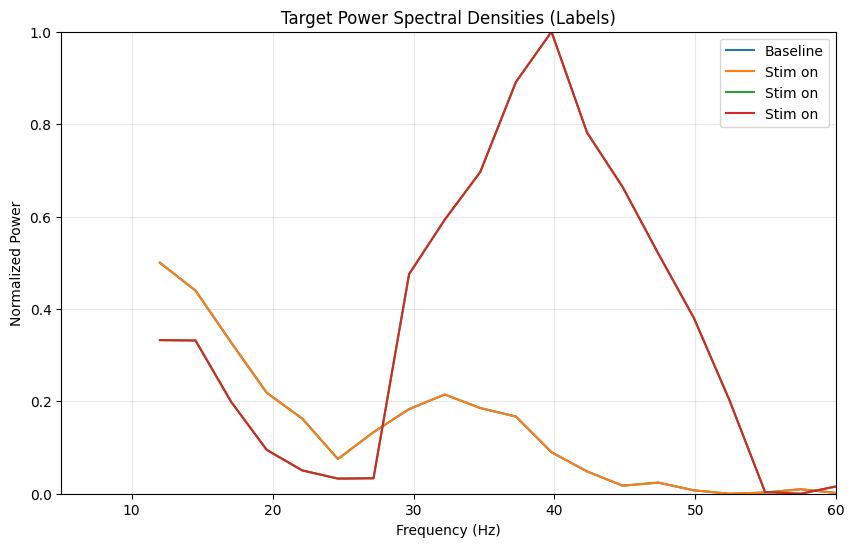

In [5]:
def get_signal_psd(traces, fs=1000):
  signal = jnp.nanmean(jnp.squeeze(traces), axis=1) # Average voltage across all recorded neurons over time
  # signal = ndimage.uniform_filter1d(signal, size=10)
  N = signal.shape[-1]

  # Compute one-sided FFT and corresponding frequencies for real signals
  signal_fft = jnp.fft.rfft(signal)
  freqs = jnp.fft.rfftfreq(N, 1/fs)
  psd_raw = jnp.abs(signal_fft)**2 / (N * fs)

  target_freqs = jnp.linspace(12.0, 60.0, 20)
  interpolated_psd = jnp.interp(target_freqs, freqs, psd_raw)
  interpolated_psd = ndimage.uniform_filter1d(interpolated_psd, size=jnp.ceil(5*jnp.sqrt(fs/1000)).astype(int))

  interpolated_psd = interpolated_psd - jnp.min(interpolated_psd)
  max_psd = jnp.max(interpolated_psd)
  scaled_psd = interpolated_psd / (max_psd + 1e-6)
  return scaled_psd


inputs = jnp.array([0.0, 0.1, 1.0, 1.1])*1.0 # nA stim amp for the three groups
labels = jnp.zeros((4, 20))

for ik in range(2):
  base_units_spectrum = get_signal_psd(selected_unit_spiking[0, :1000, :])
  labels = labels.at[ik].set(base_units_spectrum/2)

for ik in range(2, 4):
  stim_units_spectrum = get_signal_psd(selected_unit_spiking[5, 500:1500, :])
  labels = labels.at[ik].set(stim_units_spectrum)

batch_size = 4
dataloader = Dataset(inputs, labels)
dataloader = dataloader.shuffle(seed=0).batch(batch_size)

# Visualization of the labels (PSDs)
plt.figure(figsize=(10, 6))
freq_axis = jnp.linspace(12.0, 60.0, 20)

for i in range(0, labels.shape[0]):
    label_name = f"Baseline" if i < 1 else f"Stim on"
    plt.plot(freq_axis, labels[i], label=label_name)

plt.title("Target Power Spectral Densities (Labels)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power")
plt.xlim([5, 60])
plt.ylim([0, 1])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Model initilaizations

In [6]:
band_definitions = {
    'gamma': (30.0, 80.0),
    'beta': (13.0, 30.0),
    'alpha': (8.0, 13.0),
    'theta': (4.0, 8.0)
}

lower_c = 5.0
upper_c = 35.0
firing_rate_weight = 1.0
psd_weight = 99.0

dt_global = 0.1
t_max_global = 1000
t_on_global = 250

Ne = 36 # Number of Excitatory neurons
Nig = 7 # Number of Global inhibitory interneurons (SST-like)
Nil = 7 # Number of Local inhibitory interneurons (PV-like))
net = net_eig(Ne, Nig, Nil)

gAMPA_lower_bounds = 0.00
gAMPA_upper_bounds = 10.00

gGABA_lower_bounds = 0.00
gGABA_upper_bounds = 10.00

# Correctly define transform as ParamTransform for the entire parameter tree
transform = jx.ParamTransform([
    {"gAMPA": ClampTransform(gAMPA_lower_bounds, gAMPA_upper_bounds)},
    {"gGABAa": ClampTransform(gGABA_lower_bounds, gGABA_upper_bounds)}
    # {"amp_noise": ClampTransform(0, 0.1)}
])

net.delete_recordings()
net.delete_stimuli()
net.delete_trainables()

net.GradedAMPA.edge("all").make_trainable("gAMPA")
net.GradedGABAa.edge("all").make_trainable("gGABAa")
# net.cell([i for i in range(Ne + Nig + Nil)]).make_trainable("amp_noise")

# --- Pre-calculate indices for MCDP ---
# Get views for trainable synapses
view_ampa = net.GradedAMPA.edge("all")
view_gaba = net.GradedGABAa.edge("all")

# Helper to safely extract column
def get_edge_indices(view, col_candidates):
    for col in col_candidates:
        if col in view.edges.columns:
            return jnp.array(view.edges[col].values.astype(int))
    # If not found, print available columns for debugging and return empty array
    print(f"DEBUG: No candidate column found. Available columns: {list(view.edges.columns)}")
    return jnp.array([]) # Return an empty JAX array instead of raising an error

pre_candidates = ["pre_cell_idx", "pre_cell_index", "pre", "source", "pre_index"]
post_candidates = ["post_cell_idx", "post_cell_index", "post", "target", "post_index"]

ampa_pre_inds = get_edge_indices(view_ampa, pre_candidates)
ampa_post_inds = get_edge_indices(view_ampa, post_candidates)
gaba_pre_inds = get_edge_indices(view_gaba, pre_candidates)
gaba_post_inds = get_edge_indices(view_gaba, post_candidates)


@jit
def compute_correlations(traces, pre_inds, post_inds):
    """
    Computes Mutual Pearson correlation (est., time adjusted) between pre and post traces.
    traces: (Batch, Cells, Time)
    pre_inds, post_inds: (Num_Edges,)
    Returns: (Num_Edges,)
    """
    if pre_inds.size == 0 or post_inds.size == 0:
        return jnp.array([])

    # 1. Compute Raw Correlations
    pre_v = traces[:, pre_inds, :-10]
    post_v = traces[:, post_inds, 10:]

    pre_mean = jnp.mean(pre_v, axis=-1, keepdims=True)
    post_mean = jnp.mean(post_v, axis=-1, keepdims=True)
    pre_c = pre_v - pre_mean
    post_c = post_v - post_mean

    num = jnp.sum(pre_c * post_c, axis=-1)
    den = jnp.sqrt(jnp.sum(pre_c**2, axis=-1) * jnp.sum(post_c**2, axis=-1))
    corr = num**2 / (den + 1e-6) # (Batch, Num_Edges)

    # 2. Apply 2D Gaussian Smoothing on the Connectivity Matrix
    # We infer the total number of neurons from the traces shape to build a dense matrix.
    num_total_neurons = traces.shape[1]

    # Define Gaussian kernel
    k = 11
    x_grid = jnp.linspace(-2.0, 2.0, k)
    window = jnp.exp(-x_grid**2 / 2.)
    kernel = jnp.outer(window, window)
    kernel = kernel / jnp.sum(kernel)  # Normalize

    def smooth_single_batch(c_flat):
        # Map sparse edges to dense matrix (N_cells, N_cells)
        mat = jnp.zeros((num_total_neurons, num_total_neurons))
        mat = mat.at[pre_inds, post_inds].set(c_flat)

        # Convolve with 2D kernel
        smoothed_mat = jax.scipy.signal.convolve2d(mat, kernel, mode='same')

        # Extract values back to sparse edge list
        return smoothed_mat[pre_inds, post_inds]

    corr_smoothed = jax.vmap(smooth_single_batch)(corr)

    return jnp.mean(corr_smoothed, axis=0)


def calculate_mcdp(traces):
    """
    Calculates normalized MCDP factors for all trainable parameters.
    """
    # Compute raw correlations
    r_ampa = compute_correlations(traces, ampa_pre_inds, ampa_post_inds)
    r_gaba = compute_correlations(traces, gaba_pre_inds, gaba_post_inds)

    # Normalize: (val - mean) / std
    # Note: Normalization is per parameter group
    # Handle cases where r_ampa or r_gaba might be empty
    r_ampa_norm = (r_ampa - jnp.mean(r_ampa)) / (jnp.std(r_ampa) + 1e-6) if r_ampa.size > 0 else jnp.array([])
    r_gaba_norm = (r_gaba - jnp.mean(r_gaba)) / (jnp.std(r_gaba) + 1e-6) if r_gaba.size > 0 else jnp.array([])

    # Return structure matching the params PyTree
    # [{gAMPA: ...}, {gGABAa: ...}]
    return [{'gAMPA': r_ampa_norm}, {'gGABAa': r_gaba_norm}] # , {'amp_noise': jnp.array([0])}


levels = 2
# Recalculate time_points and checkpoints due to dt change
time_points = t_max_global / dt_global + 1
checkpoints = [int(np.ceil(time_points**(1/levels))) for _ in range(levels)]

# Ensure recordings are set up for the network if not already done in the model definition
net.delete_recordings()
net.cell([i for i in range(Ne+Nig+Nil)]).branch(1).loc(0.0).record()

def calculate_firing_rates(traces, spike_threshold=-20.0):
    """
    Calculates the average firing rate (spikes/second) for each neuron in the given voltage traces.

    Args:
        traces (jnp.ndarray): Array of voltage traces with shape (num_batches, num_neurons, num_timepoints).
                              The first column of each neuron's trace is assumed to be V_init and skipped.
        spike_threshold (float): The voltage threshold for detecting a spike (in mV).

    Returns:
        jnp.ndarray: Array of average firing rates (in Hz) for each neuron, with shape (num_batches, num_neurons).
    """

    # Determine the actual simulation duration excluding the initial V_init point
    num_timepoints_actual = traces.shape[-1] - 1
    # Total simulation time in milliseconds (since t_max_global is in ms)
    sim_duration_ms = t_max_global
    # Total simulation time in seconds
    sim_duration_s = sim_duration_ms / 1000.0

    def detect_spikes_for_neuron(neuron_trace):
        # Exclude the initial V_init point from the trace
        neuron_trace_data = neuron_trace[1:]
        # Detect upward crossings of the spike_threshold
        spikes = (neuron_trace_data[:-1] < spike_threshold) & (neuron_trace_data[1:] >= spike_threshold)
        return jnp.sum(spikes)

    # Vmap over neurons to get spike counts for all neurons in a single batch
    # input_axes=(0, None) means the first axis of neuron_traces is mapped, second (spike_threshold) is broadcast
    batched_detect_spikes_for_neurons = vmap(detect_spikes_for_neuron, in_axes=(0))

    # Vmap over batches to get spike counts for all batches
    # input_axes=(0) means the first axis of traces (batches) is mapped
    total_spike_counts_per_neuron_per_batch = vmap(batched_detect_spikes_for_neurons, in_axes=(0))(traces)

    # Calculate firing rate (spikes/second)
    firing_rates_hz = total_spike_counts_per_neuron_per_batch / sim_duration_s

    return firing_rates_hz


def simulate(params, input_amp):
    """
    Simulates the network for a given scalar input amplitude.
    """
    current_amp_nA = input_amp
    currents = noise_current(
        i_delay=t_on_global, i_dur=500.0,
        i_amp=current_amp_nA,
        delta_t=dt_global,
        t_max=t_max_global
    )

    # Re-enable data_stimuli
    net.delete_stimuli()
    data_stimuli = net.cell([ik for ik in range(0, Ne+Nig+Nil, 2)]).branch(0).loc(0.0).data_stimulate(currents)

    # Integrate the network dynamics.
    traces = jx.integrate(net, params=params, data_stimuli=data_stimuli, checkpoint_lengths=checkpoints)
    return traces


# Batch the simulate function for multiple input amplitudes
batched_simulate = vmap(simulate, in_axes=(None, 0))


def predict(params, input_amp):
    """
    Predicts a scaled PSD array.
    """
    traces = simulate(params, input_amp)
    signal = jnp.mean(traces[:, 1:], axis=0)

    N = signal.shape[-1]
    fs = 1000.0 / dt_global

    signal_fft = jnp.fft.rfft(signal)
    freqs = jnp.fft.rfftfreq(N, d=dt_global/1000)
    psd_raw = jnp.abs(signal_fft)**2 / (N * fs)

    target_freqs = jnp.linspace(12.0, 60.0, 20)
    interpolated_psd = jnp.interp(target_freqs, freqs, psd_raw)

    max_psd = jnp.max(interpolated_psd)
    scaled_psd = interpolated_psd / (max_psd + 1e-6)

    return scaled_psd


def loss(opt_params, inputs, labels):
    """
    Loss function for PSD fitting with firing rate penalty. Returns total loss and traces (auxiliary).
    """
    params = transform.forward(opt_params)

    # Get traces directly via batched_simulate to use for both loss and MCDP
    traces = batched_simulate(params, inputs) # Shape (Batch, Cells, Time)

    # Calculate PSDs from traces for loss
    # Helper to calculate PSD for a single trace (mean over cells)
    def compute_psd_from_trace(trace):
        # trace: (Cells, Time)
        signal = jnp.mean(trace[:, 1000:-1000], axis=0)
        N = signal.shape[-1]
        fs = 1000.0 / dt_global
        signal_fft = jnp.fft.rfft(signal)
        freqs = jnp.fft.rfftfreq(N, d=dt_global/1000)
        psd_raw = jnp.abs(signal_fft)**2 / (N * fs)

        target_freqs = jnp.linspace(12.0, 60.0, 20)
        interpolated_psd = jnp.interp(target_freqs, freqs, psd_raw)
        max_psd = jnp.max(interpolated_psd)
        return interpolated_psd / (max_psd + 1e-6)

    predictions = vmap(compute_psd_from_trace)(traces)

    epsilon = 1e-6
    psd_loss_per_sample = jnp.sum(jnp.square(labels * jnp.log((predictions + epsilon) / (labels + epsilon))), axis=1)

    # Calculate firing rates
    firing_rates = calculate_firing_rates(traces)

    # Compute firing rate penalty
    # The penalty is mean(exp(lower_c - F) + exp(F - upper_c)) over all neurons and batches
    penalty_lower = jnp.exp(lower_c - firing_rates)
    # penalty_upper = jnp.exp(firing_rates - upper_c)
    firing_rate_penalty = jnp.mean(penalty_lower) # Mean over all neurons and batches
    # jax.debug.print("Firing Rate Penalty: {}", firing_rate_penalty)

    # Combine PSD loss and firing rate penalty
    total_loss = jnp.mean(psd_loss_per_sample) * psd_weight + firing_rate_weight * firing_rate_penalty

    return total_loss, traces


# JIT the loss function and its gradient for efficiency
# has_aux=True because loss now returns (value, auxiliary_data)
jitted_grad = jit(value_and_grad(loss, argnums=0, has_aux=True))

# --- Helper Functions for Analysis ---

def compute_unscaled_psd_from_trace(trace, dt_global):
    # Assumes trace is 1D (mean signal over neurons) and already smoothed
    N = trace.shape[-1]
    fs = 1000.0 / dt_global  # dt_global is in ms, fs in Hz

    # trace is already the mean signal over neurons, 1D array of shape (Time,)
    signal = trace

    signal_fft = jnp.fft.rfft(signal)
    freqs = jnp.fft.rfftfreq(N, d=dt_global/1000)
    psd_raw = jnp.abs(signal_fft)**2 / (N * fs)

    target_freqs = jnp.linspace(1.0, 100.0, 100)
    interpolated_psd = jnp.interp(target_freqs, freqs, psd_raw)

    return target_freqs, interpolated_psd


def calculate_psd_bands(psd, freqs, band_defs):
    """
    Calculates the average absolute power within specified frequency bands from PSD data.
    Handles multi-dimensional PSD arrays (e.g. Batch x Cells x Freqs) by averaging.
    Returns a list of powers corresponding to the order of keys in band_defs.
    """
    band_powers = []
    for band_name, (f_min, f_max) in band_defs.items():
        freq_indices = (freqs >= f_min) & (freqs < f_max)

        if not jnp.any(freq_indices):
            avg_power = 0.0
        else:
            # Handle ND arrays by slicing the last dimension (frequencies)
            if psd.ndim > 1:
                band_psd_values = psd[..., freq_indices]
            else:
                band_psd_values = psd[freq_indices]

            # Average over all dimensions (Batch, Cells, Freqs in band)
            avg_power = jnp.mean(band_psd_values)

        band_powers.append(avg_power)

    return band_powers


def net_trainer_temp1(net, optimizer, dataloader, epoch_n=100, initial_params=None, optimal_params=None, training_log=None):

    if initial_params is None:
        initial_params = net.get_parameters()

    if optimal_params is None:
        print("Starting training...")
        opt_params = initial_params
    else:
        print("Continuing training...")
        opt_params = optimal_params

    if training_log is None:
            training_log = {
                "loss": [],
                "gsdr_alpha": [], # Renamed from alpha
                "loss_opt": [],
                "avg_bounded_params": [],
                "std_bounded_params": [],
                "avg_gAMPA": [],
                "std_gAMPA": [],
                "avg_gGABAa": [],
                "std_gGABAa": [],
                "mcdp_factors": [],
                "gamma_band": [],
                "beta_band": [],
                "alpha_band": [],
                "theta_band": []
              }

    opt_state = optimizer.init(opt_params)
    key = jax.random.PRNGKey(0)

    mid_params = []
    epoch_cnt = 0

    for epoch in range(epoch_n):

        key, step_key = jax.random.split(key)
        epoch_loss_accum = 0.0
        batch_count_for_avg = 0
        current_epoch_had_nan = False

        # Accumulate band powers for the epoch
        epoch_band_powers = [0.0, 0.0, 0.0, 0.0]

        for batch_ind, batch in enumerate(dataloader):
            # print("/")
            current_batch, label_batch = batch
            (loss_val, traces), gradient = jitted_grad(opt_params, current_batch, label_batch)

            # Calculate PSD and Bands for logging
            mean_traces = jnp.mean(traces, axis=1) # (Batch, Time)
            mean_trace_batch = jnp.mean(mean_traces, axis=0) # (Time,)
            freq_t, psd_t = compute_unscaled_psd_from_trace(mean_trace_batch, dt_global)
            band_powers_list = calculate_psd_bands(psd_t, freq_t, band_definitions)
            # print(band_powers_list)
            # print(freq_t)
            # print()

            for i in range(4):
                epoch_band_powers[i] += band_powers_list[i]

            if jnp.isnan(loss_val):
                print(f"Epoch {epoch}, Batch {batch_ind}: epoch voided due to nan in ODE/PDE. Reverting to last optimal state.")
                current_epoch_had_nan = True
                # GSDR.update_fn handles the reset when value=NaN is passed.
                mcdp_factors = None # No MCDP update on NaN
            else:
                epoch_loss_accum += loss_val
                batch_count_for_avg += 1
                # Calculate MCDP factors from traces
                mcdp_factors = calculate_mcdp(traces)

            current_network_params = transform.forward(opt_params)
            updates, opt_state = optimizer.update(gradient, opt_state,
                params=current_network_params,
                value=loss_val,
                key=step_key,
                mcdp_factors=mcdp_factors) # Pass MCDP factors
            opt_params = optax.apply_updates(opt_params, updates)

        # After all batches in an epoch
        if current_epoch_had_nan:
            epoch_cnt -= 1
            current_avg_loss = jnp.nan
            avg_physical_params = jnp.nan
            std_physical_params = jnp.nan
            avg_gAMPA = jnp.nan
            std_gAMPA = jnp.nan
            avg_gGABAa = jnp.nan
            std_gGABAa = jnp.nan
            avg_band_powers = [jnp.nan]*4
        elif batch_count_for_avg > 0:
            current_avg_loss = epoch_loss_accum / batch_count_for_avg

            # Params Stats
            physical_params = transform.forward(opt_params)
            all_physical_params_flat = []
            gAMPA_vals = []
            gGABAa_vals = []

            for param_group in physical_params:
                for name, param_array in param_group.items():
                    flat = param_array.flatten()
                    all_physical_params_flat.append(flat)
                    if name == 'gAMPA':
                        gAMPA_vals.append(flat)
                    elif name == 'gGABAa':
                        gGABAa_vals.append(flat)

            all_flat = jnp.concatenate(all_physical_params_flat)
            avg_physical_params = jnp.mean(all_flat)
            std_physical_params = jnp.std(all_flat)

            gAMPA_flat = jnp.concatenate(gAMPA_vals) if gAMPA_vals else jnp.array([])
            avg_gAMPA = jnp.mean(gAMPA_flat) if gAMPA_flat.size > 0 else 0.0
            std_gAMPA = jnp.std(gAMPA_flat) if gAMPA_flat.size > 0 else 0.0

            gGABAa_flat = jnp.concatenate(gGABAa_vals) if gGABAa_vals else jnp.array([])
            avg_gGABAa = jnp.mean(gGABAa_flat) if gGABAa_flat.size > 0 else 0.0
            std_gGABAa = jnp.std(gGABAa_flat) if gGABAa_flat.size > 0 else 0.0

            # Average band powers
            avg_band_powers = [p / batch_count_for_avg for p in epoch_band_powers]
        else:
            current_avg_loss = jnp.inf
            avg_physical_params = jnp.nan
            std_physical_params = jnp.nan
            avg_gAMPA = jnp.nan
            std_gAMPA = jnp.nan
            avg_gGABAa = jnp.nan
            std_gGABAa = jnp.nan
            avg_band_powers = [jnp.nan]*4

        if not current_epoch_had_nan:
          print(f"epoch {epoch_cnt}, avg. loss {current_avg_loss:.4f}, alpha {opt_state.a:.4f}, loss_opt {opt_state.loss_opt:.4f}")
          print(f"  Params: Avg={avg_physical_params:.4f}, Std={std_physical_params:.4f}")
          print(f"  gAMPA: Avg={avg_gAMPA:.4f}, Std={std_gAMPA:.4f}")
          print(f"  gGABAa: Avg={avg_gGABAa:.4f}, Std={std_gGABAa:.4f}")

          training_log["loss"].append(current_avg_loss)
          training_log["gsdr_alpha"].append(opt_state.a)
          training_log["loss_opt"].append(opt_state.loss_opt)
          training_log["avg_bounded_params"].append(avg_physical_params)
          training_log["std_bounded_params"].append(std_physical_params)

          training_log["avg_gAMPA"].append(avg_gAMPA)
          training_log["std_gAMPA"].append(std_gAMPA)
          training_log["avg_gGABAa"].append(avg_gGABAa)
          training_log["std_gGABAa"].append(std_gGABAa)

          training_log["mcdp_factors"].append(mcdp_factors)
          training_log["gamma_band"].append(avg_band_powers[0])
          training_log["beta_band"].append(avg_band_powers[1])
          training_log["alpha_band"].append(avg_band_powers[2])
          training_log["theta_band"].append(avg_band_powers[3])

        if epoch_cnt % 10 == 0 and epoch_cnt > 10:
            mid_params.append(transform.forward(opt_params))

        epoch_cnt += 1

    final_params = transform.forward(opt_params)

    return final_params, training_log, mid_params

Number of newly added trainable parameters: 1800. Total number of trainable parameters: 1800
Number of newly added trainable parameters: 420. Total number of trainable parameters: 2220
Added 50 recordings. See `.recordings` for details.


## Visualizations

Added 50 recordings. See `.recordings` for details.
Running post-training simulation with input amplitude: 1.10 nA...
Post-training simulation completed. Recorded voltages shape: (50, 15002)


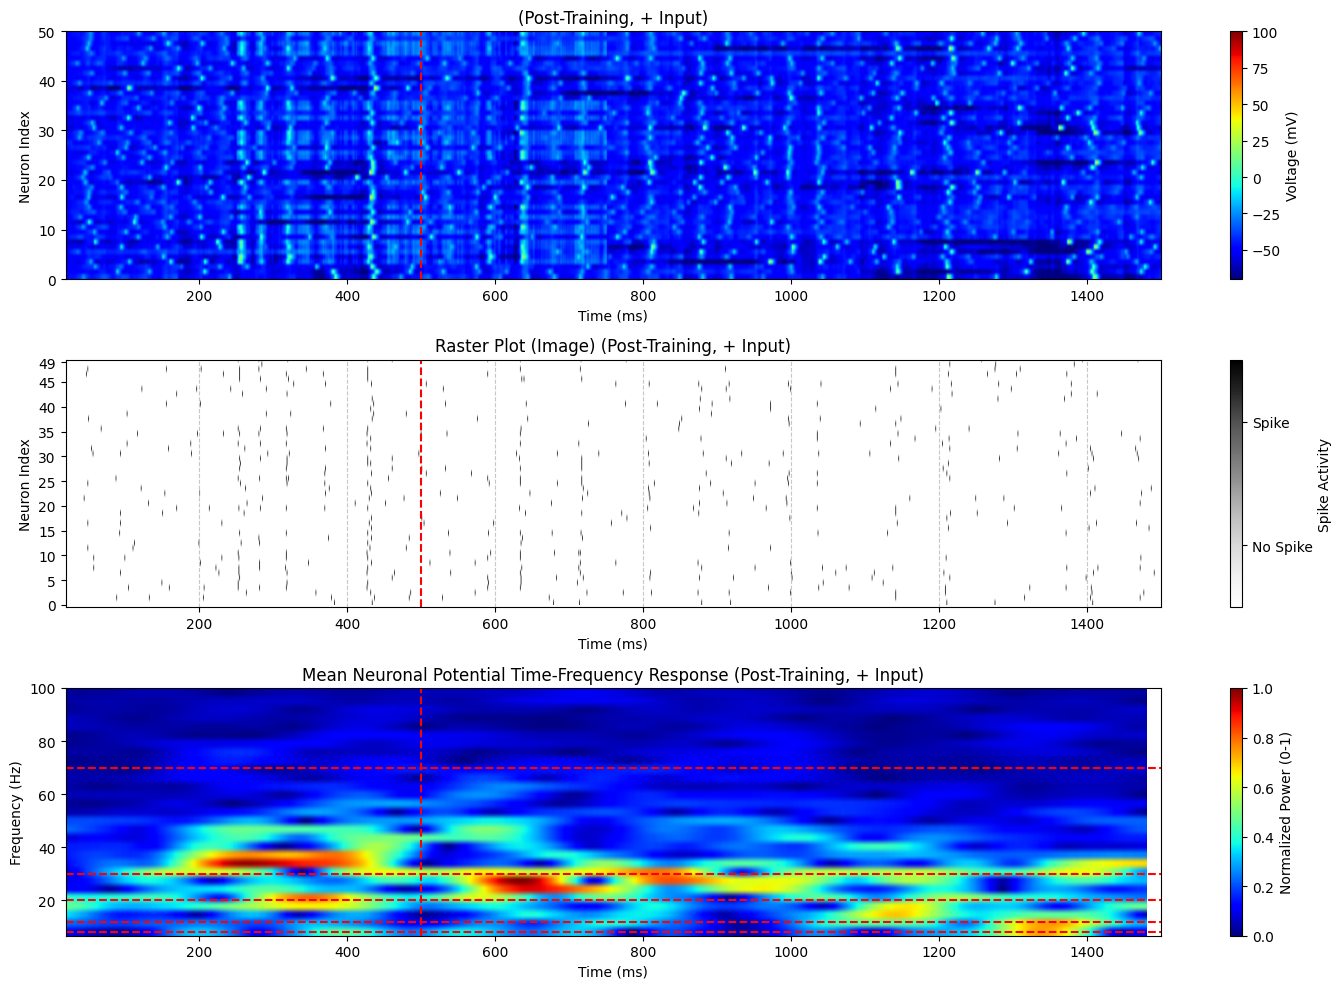

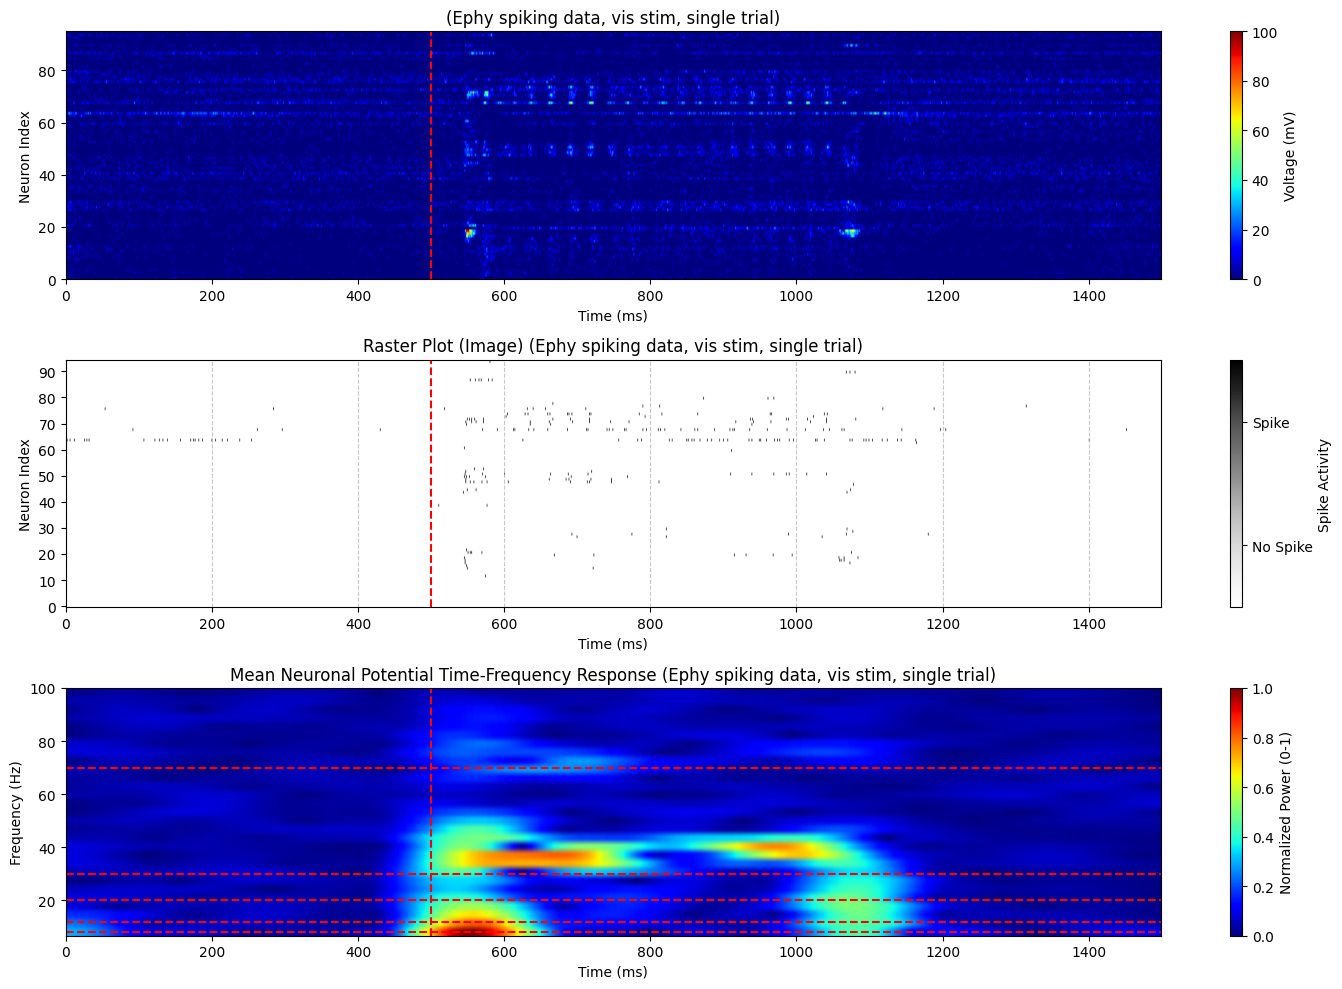

In [6]:
from datetime import time
# net.set("gAMPA", 0.05)
# net.cell([i for i in range(Ne, Ne + Nig + Nil)]).set("amp_noise", 0.1)
# net.cell([i for i in range(Ne, Ne + Nig + Nil)]).set("mean", -0.001)
# net.cell([i for i in range(Ne)]).set("amp_noise", 0.1)
# net.cell([i for i in range(Ne)]).set("mean", -0.001)

t_max_vs = 1500
levels = 2
time_points_vs = t_max_vs / dt_global + 1
checkpoints_vs = [int(np.ceil(time_points_vs**(1/levels))) for _ in range(levels)]


single_input_amp = inputs[3]
sim_noise_current_pulse = noise_current(
    i_delay=250,
    i_dur=500.0,
    i_amp=single_input_amp,
    delta_t=dt_global,
    t_max=t_max_vs
)

# sim_noise_current_pulse = noise_current_ac(
#     i_delay = t_on_global,
#     i_dur = 500.0, amp_n=0.1,
#     amp_b=inputs[3], delta_t = dt_global,
#     t_max = t_max_global, spect=jnp.array([1.0]) # Changed 10 to jnp.array([10.0])
# )

this_params = net.get_parameters()

net.delete_stimuli()
net.delete_recordings()
num_posts_to_select = 22
posts_pool_indices = jnp.concat([jnp.arange(0, Ne), jnp.arange(Ne + Nig, Ne + Nig + Nil)])
key_conn = jax.random.PRNGKey(5678)
selected_post_indices = np.array(jax.random.choice(key_conn, posts_pool_indices, shape=(num_posts_to_select,), replace=False))

data_stimuli_single_run = net.cell(selected_post_indices).branch(1).loc(0.0).data_stimulate(sim_noise_current_pulse) # Changed loc(1.0) to loc(0.0)
net.cell([i for i in range(Ne+Nig+Nil)]).branch(1).loc(0.0).record()

print(f"Running post-training simulation with input amplitude: {single_input_amp:.2f} nA...")
recorded_voltages_pre_training = jx.integrate(net, params=this_params, data_stimuli=data_stimuli_single_run, checkpoint_lengths=checkpoints_vs)
print(f"Post-training simulation completed. Recorded voltages shape: {recorded_voltages_pre_training.shape}")
time_axis = jnp.arange(20, t_max_vs, dt_global)

temp_data_spec = jnp.mean(selected_unit_spiking[:, 500:, :], 0).T

plot_full_simulation_summary(recorded_voltages_pre_training[:, 200:], time_axis, dt_global,
                             spike_threshold=-20.0,
                             window_size=300.0, overlap=0.99,
                             f_min=4.0, f_max=100.0,
                             title_suffix="(Post-Training, + Input)",
                             save=True, save_fname=figure_save_path+"/v_model_init_0.svg")

plot_full_simulation_summary(temp_data_spec, jnp.arange(0, 1500, 1), 1.0,
                             spike_threshold=20.0,
                             window_size=300.0, overlap=0.99,
                             f_min=4.0, f_max=100.0,
                             title_suffix="(Ephy spiking data, vis stim, single trial)",
                             save=True, save_fname=figure_save_path+"/v_data_s0.svg")

## Optimization

## Stable spectral tuning

In [ ]:
key = jax.random.PRNGKey(421)
initial_params_0 = net.get_parameters()
model_save_name = "model_000_gda"
optimizer_inner = optax.sgd(learning_rate=1e-2, momentum=0.01)

optimizer = GSDR(
    inner_optimizer=optimizer_inner,
    delta_distribution=jax.random.normal,
    deselection_threshold=1.5,
    a_init=0.0,
    a_dynamic=True,
    lambda_d=1.0,
    checkpoint_n=6,
    mcdp=True
)

final_params_0, log_net_0, mid_params_0 = net_trainer_temp1(net, optimizer, dataloader, 500)
save_jnn(model_save_name, model_save_path, net, initial_params_0, mid_params_0, final_params_0, log_net_0)

In [ ]:
key = jax.random.PRNGKey(421)
initial_params_0 = net.get_parameters()
model_save_name = "model_000_sta"
optimizer_inner = optax.sgd(learning_rate=1e-2, momentum=0.01)

optimizer = GSDR(
    inner_optimizer=optimizer_inner,
    delta_distribution=jax.random.normal,
    deselection_threshold=1.5,
    a_init=0.0,
    a_dynamic=False,
    lambda_d=1.0,
    checkpoint_n=6,
    mcdp=True
)

final_params_0, log_net_0, mid_params_0 = net_trainer_temp1(net, optimizer, dataloader, 500)
save_jnn(model_save_name, model_save_path, net, initial_params_0, mid_params_0, final_params_0, log_net_0)

Starting training...
GSDR: Avg Inner Update: -0.15495495495495495, Std Inner Update: 0.9879215363250807
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: -0.15495495495495495, Std Combined Update: 0.9879215363250807
epoch 0, avg. loss 3339.4089, alpha 0.0000, loss_opt 3339.4089, Avg Bounded Params: 2.3991, Std Bounded Params: 2.2258
GSDR: Avg Inner Update: -0.14324324324324325, Std Inner Update: 0.9896875129378754
GSDR: Avg Delta (Noise): 0.0029364461888703878, Std Delta (Noise): 0.11817044262085974
GSDR: Avg Combined Update: -0.14324324324324325, Std Combined Update: 0.9896875129378754
epoch 1, avg. loss 3669.0507, alpha 0.0000, loss_opt 3339.4089, Avg Bounded Params: 2.4068, Std Bounded Params: 2.7932
GSDR: Avg Inner Update: -0.3646668268089461, Std Inner Update: 0.9299372225871928
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: -0.3646668268089461, Std Combined Update: 0.9299372225871928
epoch 2, avg. loss 2628.6437, alph

In [ ]:
key = jax.random.PRNGKey(421)
initial_params_0 = net.get_parameters()
model_save_name = "model_002_sa"
optimizer_inner = optax.sgd(learning_rate=1e-2, momentum=0.1)

optimizer = GSDR(
    inner_optimizer=optimizer_inner,
    delta_distribution=jax.random.normal,
    deselection_threshold=1.5,
    a_init=0.2,
    a_dynamic=False,
    lambda_d=1.0,
    checkpoint_n=6,
    mcdp=True
)

final_params_0, log_net_0, mid_params_0 = net_trainer_temp1(net, optimizer, dataloader, 500)
save_jnn(model_save_name, model_save_path, net, initial_params_0, mid_params_0, final_params_0, log_net_0)

Starting training...
GSDR: Avg Inner Update: -0.15495495495495495, Std Inner Update: 0.9879215363250807
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: -0.12396396396396399, Std Combined Update: 0.7903372290600646
epoch 0, avg. loss 3339.4089, alpha 0.2000, loss_opt 3339.4089, Avg Bounded Params: 2.4301, Std Bounded Params: 2.1069
GSDR: Avg Inner Update: -0.15585585585585585, Std Inner Update: 0.9877798095706546
GSDR: Avg Delta (Noise): 0.0035506582646790195, Std Delta (Noise): 0.11442811230353446
GSDR: Avg Combined Update: -0.1239745530317489, Std Combined Update: 0.7915513468479365
epoch 1, avg. loss 3902.8868, alpha 0.2000, loss_opt 3339.4089, Avg Bounded Params: 2.3062, Std Bounded Params: 2.6371
GSDR: Avg Inner Update: 0.010810810810810811, Std Inner Update: 0.9999415614772759
GSDR: Avg Delta (Noise): 0.010150893702987803, Std Delta (Noise): 0.3986608121009872
GSDR: Avg Combined Update: 0.010678827389246207, Std Combined Update: 0.8047199910775573
e

In [ ]:
key = jax.random.PRNGKey(421)
initial_params_0 = net.get_parameters()
model_save_name = "model_004_sa"
optimizer_inner = optax.sgd(learning_rate=1e-2, momentum=0.1)

optimizer = GSDR(
    inner_optimizer=optimizer_inner,
    delta_distribution=jax.random.normal,
    deselection_threshold=1.5,
    a_init=0.4,
    a_dynamic=False,
    lambda_d=1.0,
    checkpoint_n=6,
    mcdp=True
)

final_params_0, log_net_0, mid_params_0 = net_trainer_temp1(net, optimizer, dataloader, 500)
save_jnn(model_save_name, model_save_path, net, initial_params_0, mid_params_0, final_params_0, log_net_0)

Starting training...
GSDR: Avg Inner Update: -0.00041616615644771333, Std Inner Update: 0.9942418071877289
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: -0.00024969969386862866, Std Combined Update: 0.5965450843126373
epoch 0, avg. loss 3103.7970, alpha 0.4000, loss_opt 3103.7970, Avg Bounded Params: 1.7306, Std Bounded Params: 1.1709
GSDR: Avg Inner Update: 0.05045045045045045, Std Inner Update: 0.9987265652065868
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: 0.030270270270270266, Std Combined Update: 0.5992359391239521
epoch 1, avg. loss 3041.6262, alpha 0.4000, loss_opt 3041.6262, Avg Bounded Params: 1.7609, Std Bounded Params: 1.3011
GSDR: Avg Inner Update: 0.04954954954954955, Std Inner Update: 0.9987716666683316
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: 0.029729729729729724, Std Combined Update: 0.5992630000009989
epoch 2, avg. loss 1612.2528, alpha 0.4000, loss_opt 1612.2528

In [ ]:
key = jax.random.PRNGKey(421)
initial_params_0 = net.get_parameters()
model_save_name = "model_006_sa"
optimizer_inner = optax.sgd(learning_rate=1e-2, momentum=0.1)

optimizer = GSDR(
    inner_optimizer=optimizer_inner,
    delta_distribution=jax.random.normal,
    deselection_threshold=1.5,
    a_init=0.6,
    a_dynamic=False,
    lambda_d=1.0,
    checkpoint_n=6,
    mcdp=True
)

final_params_0, log_net_0, mid_params_0 = net_trainer_temp1(net, optimizer, dataloader, 500)
save_jnn(model_save_name, model_save_path, net, initial_params_0, mid_params_0, final_params_0, log_net_0)

Starting training...
GSDR: Avg Inner Update: -0.00041616615644769734, Std Inner Update: 0.9942418071877289
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: -0.0001664664625790783, Std Combined Update: 0.39769672287509156
epoch 0, avg. loss 3103.7970, alpha 0.6000, loss_opt 3103.7970, Avg Bounded Params: 1.7307, Std Bounded Params: 1.0888
GSDR: Avg Inner Update: 0.005336611782543616, Std Inner Update: 0.9486493976297997
GSDR: Avg Delta (Noise): 0.0018608898740298217, Std Delta (Noise): 0.10218169375017604
GSDR: Avg Combined Update: 0.0032511786374353367, Std Combined Update: 0.3855378256063497
epoch 1, avg. loss 3173.9435, alpha 0.6000, loss_opt 3103.7970, Avg Bounded Params: 1.7340, Std Bounded Params: 1.2661
GSDR: Avg Inner Update: 0.010831677999330004, Std Inner Update: 0.8368909177530592
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: 0.004332671199732, Std Combined Update: 0.3347563671012237
epoch 2, avg. loss 2444.8043

In [ ]:
key = jax.random.PRNGKey(421)
initial_params_0 = net.get_parameters()
model_save_name = "model_008_sa"
optimizer_inner = optax.sgd(learning_rate=1e-2, momentum=0.1)

optimizer = GSDR(
    inner_optimizer=optimizer_inner,
    delta_distribution=jax.random.normal,
    deselection_threshold=1.5,
    a_init=0.8,
    a_dynamic=False,
    lambda_d=1.0,
    checkpoint_n=6,
    mcdp=True
)

final_params_0, log_net_0, mid_params_0 = net_trainer_temp1(net, optimizer, dataloader, 500)
save_jnn(model_save_name, model_save_path, net, initial_params_0, mid_params_0, final_params_0, log_net_0)

Starting training...
GSDR: Avg Inner Update: -0.02761648915203772, Std Inner Update: 0.9732479507485188
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: -0.005523297830407542, Std Combined Update: 0.1946495901497037
epoch 0, avg. loss 2050.9674, alpha 0.8000, loss_opt 2050.9674, Avg Bounded Params: 1.9882, Std Bounded Params: 2.0001
GSDR: Avg Inner Update: -0.01922943213687906, Std Inner Update: 0.8822191680119577
GSDR: Avg Delta (Noise): 0.0011452044501619938, Std Delta (Noise): 0.08397112923824031
GSDR: Avg Combined Update: -0.0029297228672462124, Std Combined Update: 0.18862703369135922
epoch 1, avg. loss 2114.4333, alpha 0.8000, loss_opt 2050.9674, Avg Bounded Params: 1.9852, Std Bounded Params: 2.0221
GSDR: Avg Inner Update: 0.04247899191877311, Std Inner Update: 0.9733010593754051
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: 0.008495798383754615, Std Combined Update: 0.19466021187508098
epoch 2, avg. loss 1974.1956

In [ ]:
key = jax.random.PRNGKey(421)
initial_params_0 = net.get_parameters()
model_save_name = "model_010_sa"
optimizer_inner = optax.sgd(learning_rate=1e-2, momentum=0.1)

optimizer = GSDR(
    inner_optimizer=optimizer_inner,
    delta_distribution=jax.random.normal,
    deselection_threshold=1.5,
    a_init=1.0,
    a_dynamic=False,
    lambda_d=1.0,
    checkpoint_n=6,
    mcdp=True
)

final_params_0, log_net_0, mid_params_0 = net_trainer_temp1(net, optimizer, dataloader, 500)
save_jnn(model_save_name, model_save_path, net, initial_params_0, mid_params_0, final_params_0, log_net_0)

Starting training...
GSDR: Avg Inner Update: -0.02761648915203771, Std Inner Update: 0.9732479507485188
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: 0.0, Std Combined Update: 0.0
epoch 0, avg. loss 2050.9674, alpha 1.0000, loss_opt 2050.9674, Avg Bounded Params: 1.9937, Std Bounded Params: 1.9904
GSDR: Avg Inner Update: -0.027987603121373057, Std Inner Update: 0.9751208359675213
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: 0.0, Std Combined Update: 0.0
epoch 1, avg. loss 2050.9674, alpha 1.0000, loss_opt 2050.9674, Avg Bounded Params: 1.9937, Std Bounded Params: 1.9904
GSDR: Avg Inner Update: -0.02802000584467378, Std Inner Update: 0.9752904536543825
GSDR: Avg Delta (Noise): 0.000288510789314968, Std Delta (Noise): 0.08163426509932235
GSDR: Avg Combined Update: 0.000288510789314968, Std Combined Update: 0.08163426509932235
epoch 2, avg. loss 2050.9674, alpha 1.0000, loss_opt 2050.9674, Avg Bounded Params: 1.9940, Std

In [ ]:
key = jax.random.PRNGKey(421)
initial_params_0 = net.get_parameters()
model_save_name = "model_001_sa"
optimizer_inner = optax.sgd(learning_rate=1e-2, momentum=0.1)

optimizer = GSDR(
    inner_optimizer=optimizer_inner,
    delta_distribution=jax.random.normal,
    deselection_threshold=1.5,
    a_init=0.05,
    a_dynamic=False,
    lambda_d=1.0,
    checkpoint_n=6,
    mcdp=True
)

final_params_0, log_net_0, mid_params_0 = net_trainer_temp1(net, optimizer, dataloader, 500)
save_jnn(model_save_name, model_save_path, net, initial_params_0, mid_params_0, final_params_0, log_net_0)

Starting training...
GSDR: Avg Inner Update: -0.00041616615644766536, Std Inner Update: 0.9942418071877289
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: -0.00039535784862527974, Std Combined Update: 0.9445297168283424
epoch 0, avg. loss 3103.7970, alpha 0.0500, loss_opt 3103.7970, Avg Bounded Params: 1.7305, Std Bounded Params: 1.3734
GSDR: Avg Inner Update: -0.016257273127300874, Std Inner Update: 0.9831875738256636
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: -0.015444409470935835, Std Combined Update: 0.9340281951343804
epoch 1, avg. loss 1917.8479, alpha 0.0500, loss_opt 1917.8479, Avg Bounded Params: 1.9002, Std Bounded Params: 1.6567
GSDR: Avg Inner Update: -0.2204379307960285, Std Inner Update: 0.9300063529819653
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: -0.20941603425622707, Std Combined Update: 0.883506035332867
epoch 2, avg. loss 1894.6503, alpha 0.0500, loss_opt 1894.65

### Q2

In [7]:
key = jax.random.PRNGKey(421)
initial_params_0 = net.get_parameters()
model_save_name = "model_000_dynamic"
optimizer_inner = optax.sgd(learning_rate=4e-3, momentum=0.01)

optimizer = GSDR(
    inner_optimizer=optimizer_inner,
    delta_distribution=jax.random.normal,
    deselection_threshold=3.0,
    a_init=0.0,
    a_dynamic=True,
    lambda_d=1.0,
    checkpoint_n=5,
    mcdp=True
)

final_params_0, log_net_0, mid_params_0 = net_trainer_temp1(net, optimizer, dataloader, 500)
save_jnn(model_save_name, model_save_path, net, initial_params_0, mid_params_0, final_params_0, log_net_0)

Starting training...
GSDR: Avg Inner Update: -0.011155553028025306, Std Inner Update: 0.9264023162590244
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: -0.010268322943673743, Std Combined Update: 0.8527231357528585
epoch 0, avg. loss 265.0292, alpha 0.0795, loss_opt 265.0292
  Params: Avg=1.7206, Std=1.3172
  gAMPA: Avg=1.2415, Std=0.8537
  gGABAa: Avg=3.7737, Std=0.9209
GSDR: Avg Inner Update: 0.02100110868963347, Std Inner Update: 0.992508835379782
GSDR: Avg Delta (Noise): 0.001719154543082398, Std Delta (Noise): 0.12986476310590508
GSDR: Avg Combined Update: 0.020531490488985078, Std Combined Update: 0.9683211961897438
epoch 1, avg. loss 521.6991, alpha 0.0244, loss_opt 265.0292
  Params: Avg=1.8550, Std=1.4589
  gAMPA: Avg=1.4171, Std=1.1090
  gGABAa: Avg=3.7317, Std=1.2792
>Deselection(Divergence)
epoch 2, avg. loss 1074.5914, alpha 0.0000, loss_opt 265.0292
  Params: Avg=1.6170, Std=1.1061
  gAMPA: Avg=1.1000, Std=0.2653
  gGABAa: Avg=3.8329, Std=

In [8]:
key = jax.random.PRNGKey(421)
initial_params_0 = net.get_parameters() # 265
model_save_name = "model_000_sta"
optimizer_inner = optax.sgd(learning_rate=4e-3, momentum=0.01)

optimizer = GSDR(
    inner_optimizer=optimizer_inner,
    delta_distribution=jax.random.normal,
    deselection_threshold=3.0,
    a_init=0.0,
    a_dynamic=False,
    lambda_d=1.0,
    checkpoint_n=5,
    mcdp=True
)

final_params_0, log_net_0, mid_params_0 = net_trainer_temp1(net, optimizer, dataloader, 400)
save_jnn(model_save_name, model_save_path, net, initial_params_0, mid_params_0, final_params_0, log_net_0)

Starting training...
GSDR: Avg Inner Update: -0.011155553028025293, Std Inner Update: 0.9264023162590242
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: -0.011155553028025293, Std Combined Update: 0.9264023162590242
epoch 0, avg. loss 265.0292, alpha 0.0000, loss_opt 265.0292
  Params: Avg=1.7197, Std=1.3646
  gAMPA: Avg=1.2416, Std=0.9274
  gGABAa: Avg=3.7686, Std=0.9896
GSDR: Avg Inner Update: 0.0029213597927375758, Std Inner Update: 0.25742684354434286
GSDR: Avg Delta (Noise): 0.001594216236103334, Std Delta (Noise): 0.12902757685335325
GSDR: Avg Combined Update: 0.0029213597927375758, Std Combined Update: 0.25742684354434286
epoch 1, avg. loss 348.9982, alpha 0.0000, loss_opt 265.0292
  Params: Avg=1.7398, Std=1.4488
  gAMPA: Avg=1.2684, Std=1.0506
  gGABAa: Avg=3.7602, Std=1.1529
GSDR: Avg Inner Update: -0.0031945965218204814, Std Inner Update: 0.10502464183187947
GSDR: Avg Delta (Noise): -0.0008399555317646877, Std Delta (Noise): 0.4675923861230423

In [8]:
key = jax.random.PRNGKey(421)
initial_params_0 = net.get_parameters()
model_save_name = "model_002_sa"
optimizer_inner = optax.sgd(learning_rate=4e-3, momentum=0.01)

optimizer = GSDR(
    inner_optimizer=optimizer_inner,
    delta_distribution=jax.random.normal,
    deselection_threshold=3.0,
    a_init=0.2,
    a_dynamic=False,
    lambda_d=1.0,
    checkpoint_n=5,
    mcdp=True
)

final_params_0, log_net_0, mid_params_0 = net_trainer_temp1(net, optimizer, dataloader, 500)
save_jnn(model_save_name, model_save_path, net, initial_params_0, mid_params_0, final_params_0, log_net_0)

Starting training...
GSDR: Avg Inner Update: -4.384477994889045e-05, Std Inner Update: 0.07567853115691398
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: -3.5075823959112526e-05, Std Combined Update: 0.06054282492553119
epoch 0, avg. loss 1265.6991, alpha 0.2000, loss_opt 1265.6991
  Params: Avg=2.5772, Std=0.2747
  gAMPA: Avg=2.4478, Std=0.0427
  gGABAa: Avg=3.1315, Std=0.1103
GSDR: Avg Inner Update: 9.688187116481232e-05, Std Inner Update: 0.025802039910756164
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: 7.750549693184986e-05, Std Combined Update: 0.020641631928604933
epoch 1, avg. loss 1120.1781, alpha 0.2000, loss_opt 1120.1781
  Params: Avg=2.5773, Std=0.2749
  gAMPA: Avg=2.4482, Std=0.0451
  gGABAa: Avg=3.1304, Std=0.1164
GSDR: Avg Inner Update: 9.686026098303675e-05, Std Inner Update: 0.06282980005720533
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: 7.748820878642967e-05, Std Co

In [9]:
key = jax.random.PRNGKey(421)
initial_params_0 = net.get_parameters()
model_save_name = "model_004_sa"
optimizer_inner = optax.sgd(learning_rate=4e-3, momentum=0.01)

optimizer = GSDR(
    inner_optimizer=optimizer_inner,
    delta_distribution=jax.random.normal,
    deselection_threshold=3.0,
    a_init=0.4,
    a_dynamic=False,
    lambda_d=1.0,
    checkpoint_n=5,
    mcdp=True
)

final_params_0, log_net_0, mid_params_0 = net_trainer_temp1(net, optimizer, dataloader, 500)
save_jnn(model_save_name, model_save_path, net, initial_params_0, mid_params_0, final_params_0, log_net_0)

Starting training...
GSDR: Avg Inner Update: 0.006442392605551375, Std Inner Update: 0.3824436261318515
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: 0.0038654355633308225, Std Combined Update: 0.22946617567911087
epoch 0, avg. loss 1265.6991, alpha 0.4000, loss_opt 1265.6991
  Params: Avg=2.5811, Std=0.3486
  gAMPA: Avg=2.4543, Std=0.2037
  gGABAa: Avg=3.1246, Std=0.3162
GSDR: Avg Inner Update: -0.002953213094772378, Std Inner Update: 0.7242015065754654
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: -0.001771927856863425, Std Combined Update: 0.43452090394527926
epoch 1, avg. loss 963.8627, alpha 0.4000, loss_opt 963.8627
  Params: Avg=2.5793, Std=0.5476
  gAMPA: Avg=2.4570, Std=0.4592
  gGABAa: Avg=3.1033, Std=0.5853
GSDR: Avg Inner Update: 0.010606450975348005, Std Inner Update: 0.5489887459735184
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: 0.006363870585208805, Std Combined Update

In [8]:
key = jax.random.PRNGKey(421)
initial_params_0 = net.get_parameters()
# initial_params_0 = loaded_initial_params[9]

model_save_name = "model_006_sa"
optimizer_inner = optax.sgd(learning_rate=4e-3, momentum=0.01)

optimizer = GSDR(
    inner_optimizer=optimizer_inner,
    delta_distribution=jax.random.normal,
    deselection_threshold=3.0,
    a_init=0.6,
    a_dynamic=False,
    lambda_d=1.0,
    checkpoint_n=5,
    mcdp=True
)

final_params_0, log_net_0, mid_params_0 = net_trainer_temp1(net, optimizer, dataloader, 500, initial_params=initial_params_0)
save_jnn(model_save_name, model_save_path, net, initial_params_0, mid_params_0, final_params_0, log_net_0)

Starting training...
GSDR: Avg Inner Update: 0.000715271293785815, Std Inner Update: 0.07283889505380342
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: 0.00028610851751432613, Std Combined Update: 0.02913555802152137
epoch 0, avg. loss 368.5510, alpha 0.6000, loss_opt 368.5510
  Params: Avg=2.5775, Std=0.2679
  gAMPA: Avg=2.4490, Std=0.0222
  gGABAa: Avg=3.1284, Std=0.0556
GSDR: Avg Inner Update: -0.004213080880645841, Std Inner Update: 0.21901162920935452
GSDR: Avg Delta (Noise): 0.0026824095545943797, Std Delta (Noise): 0.2030772348635019
GSDR: Avg Combined Update: -7.57866195017089e-05, Std Combined Update: 0.15109908193030688
epoch 1, avg. loss 450.1154, alpha 0.6000, loss_opt 368.5510
  Params: Avg=2.5774, Std=0.3084
  gAMPA: Avg=2.4463, Std=0.1500
  gGABAa: Avg=3.1396, Std=0.1280
GSDR: Avg Inner Update: 0.0015133491237868764, Std Inner Update: 0.07250275281152047
GSDR: Avg Delta (Noise): 0.004243389275314686, Std Delta (Noise): 0.6907007044181388


In [9]:
key = jax.random.PRNGKey(421)
initial_params_0 = net.get_parameters()
model_save_name = "model_008_sa"
optimizer_inner = optax.sgd(learning_rate=4e-3, momentum=0.01)

optimizer = GSDR(
    inner_optimizer=optimizer_inner,
    delta_distribution=jax.random.normal,
    deselection_threshold=3.0,
    a_init=0.8,
    a_dynamic=False,
    lambda_d=1.0,
    checkpoint_n=5,
    mcdp=True
)

final_params_0, log_net_0, mid_params_0 = net_trainer_temp1(net, optimizer, dataloader, 500)
save_jnn(model_save_name, model_save_path, net, initial_params_0, mid_params_0, final_params_0, log_net_0)

Starting training...
GSDR: Avg Inner Update: -0.008667209174388272, Std Inner Update: 0.9875635851028205
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: -0.0017334418348776527, Std Combined Update: 0.19751271702056405
epoch 0, avg. loss 265.0292, alpha 0.8000, loss_opt 265.0292
  Params: Avg=1.7291, Std=1.0396
  gAMPA: Avg=1.2412, Std=0.1975
  gGABAa: Avg=3.8202, Std=0.3909
GSDR: Avg Inner Update: 0.07102423843259288, Std Inner Update: 0.9775346063262144
GSDR: Avg Delta (Noise): 0.0015841604271570327, Std Delta (Noise): 0.10801421482634693
GSDR: Avg Combined Update: 0.015472176028244198, Std Combined Update: 0.21220351248435834
epoch 1, avg. loss 321.2414, alpha 0.8000, loss_opt 265.0292
  Params: Avg=1.7446, Std=1.0497
  gAMPA: Avg=1.2627, Std=0.3003
  gGABAa: Avg=3.8099, Std=0.4207
GSDR: Avg Inner Update: -0.008073111420470758, Std Inner Update: 0.8907521070971637
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: -0.001614

In [34]:
key = jax.random.PRNGKey(421)
initial_params_0 = net.get_parameters()
model_save_name = "model_010_sa"
optimizer_inner = optax.sgd(learning_rate=4e-3, momentum=0.01)

optimizer = GSDR(
    inner_optimizer=optimizer_inner,
    delta_distribution=jax.random.normal,
    deselection_threshold=3.0,
    a_init=1.0,
    a_dynamic=False,
    lambda_d=1.0,
    checkpoint_n=5,
    mcdp=True
)

final_params_0, log_net_0, mid_params_0 = net_trainer_temp1(net, optimizer, dataloader, 500)
save_jnn(model_save_name, model_save_path, net, initial_params_0, mid_params_0, final_params_0, log_net_0)

Starting training...
GSDR: Avg Inner Update: -0.008736329174445575, Std Inner Update: 0.979675001002998
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: 0.0, Std Combined Update: 0.0
epoch 0, avg. loss 265.0292, alpha 1.0000, loss_opt 265.0292
  Params: Avg=1.7309, Std=1.0255
  gAMPA: Avg=1.2404, Std=0.0000
  gGABAa: Avg=3.8329, Std=0.3306
GSDR: Avg Inner Update: -0.008720088862586461, Std Inner Update: 0.9799239222416625
GSDR: Avg Delta (Noise): 0.0009976468875445346, Std Delta (Noise): 0.10632800636053967
GSDR: Avg Combined Update: 0.0009976468875445346, Std Combined Update: 0.10632800636053967
epoch 1, avg. loss 265.0292, alpha 1.0000, loss_opt 265.0292
  Params: Avg=1.7319, Std=1.0305
  gAMPA: Avg=1.2416, Std=0.1181
  gGABAa: Avg=3.8329, Std=0.3306
GSDR: Avg Inner Update: -0.01234175080197395, Std Inner Update: 0.992254703139691
GSDR: Avg Delta (Noise): 0.001262791285366609, Std Delta (Noise): 0.503436761043229
GSDR: Avg Combined Update: 0.00126279128

In [ ]:
key = jax.random.PRNGKey(421)
initial_params_0 = net.get_parameters()
model_save_name = "model_001_sa"
optimizer_inner = optax.sgd(learning_rate=4e-3, momentum=0.01)

optimizer = GSDR(
    inner_optimizer=optimizer_inner,
    delta_distribution=jax.random.normal,
    deselection_threshold=3.0,
    a_init=0.05,
    a_dynamic=False,
    lambda_d=1.0,
    checkpoint_n=5,
    mcdp=True
)

final_params_0, log_net_0, mid_params_0 = net_trainer_temp1(net, optimizer, dataloader, 400)
save_jnn(model_save_name, model_save_path, net, initial_params_0, mid_params_0, final_params_0, log_net_0)

Starting training...
GSDR: Avg Inner Update: -0.008736329174445577, Std Inner Update: 0.979675001002998
GSDR: Avg Delta (Noise): 0.0, Std Delta (Noise): 0.0
GSDR: Avg Combined Update: -0.008299512715723302, Std Combined Update: 0.930691250952848
epoch 0, avg. loss 265.0292, alpha 0.0500, loss_opt 265.0292
  Params: Avg=1.7226, Std=1.3685
  gAMPA: Avg=1.2438, Std=0.9300
  gGABAa: Avg=3.7745, Std=0.9999
GSDR: Avg Inner Update: -0.027285082921254606, Std Inner Update: 0.9716050751085235
GSDR: Avg Delta (Noise): 0.0020937470177183714, Std Delta (Noise): 0.13124279528308302
GSDR: Avg Combined Update: -0.025816141424305945, Std Combined Update: 0.9230350151013226
epoch 1, avg. loss 391.0817, alpha 0.0500, loss_opt 265.0292
  Params: Avg=1.8292, Std=1.5408
  gAMPA: Avg=1.3529, Std=1.1196
  gGABAa: Avg=3.8705, Std=1.4274
GSDR: Avg Inner Update: -0.07289475130184579, Std Inner Update: 0.8567699135985296
GSDR: Avg Delta (Noise): -0.004881834309014988, Std Delta (Noise): 0.4618785384248122
GSDR: 

In [ ]:
# LOAD all models in path and plot each ones:

# Load all "model_gsg_a***" models
# Visualize:
# >subplot(4, 1, 1): Loss+- per trial (redline)
# >subplot(4, 1, 2): Correlation to data per trial (LogCor)
# >subplot(4, 1, 3): Relative gamma+-, beta+- and alpha+- per trial
# >>solid line for gamma 35-45Hz, dashed line for broadband gamma 35Hz+
# >>dashed lines for alpha 8-12Hz and beta 12-30Hz
# >subplot(4, 1, 4): Firing rate and ISI per neuron type, model and trial est
# Visualize:
# >subplot(2, 2, 1): initial connectivity (50 in 50) with neurons 1-50 (EX/INg/INl)
# >subplot(2, 2, 2): final connectivity
# >subplot(2, 2, 3): initial MCDP matrix
# >subplot(2, 2, 4): final MCDP matrix

## Visualization

In [35]:
loaded_nets = []
loaded_initial_params = []
loaded_mid_params = []
loaded_final_params = []
loaded_log_nets = []
cnt = 0

for file in os.listdir(model_save_path):
    loaded_net, loaded_initial_param, loaded_mid_param, loaded_final_param, loaded_log_net = load_jnn(file, model_save_path)
    loaded_nets.append(loaded_net)
    loaded_initial_params.append(loaded_initial_param)
    loaded_mid_params.append(loaded_mid_param)
    loaded_final_params.append(loaded_final_param)
    loaded_log_nets.append(loaded_log_net)


Model components loaded from /content/data/NeuralCircuits/model_000_dynamica.pkl
Model components loaded from /content/data/NeuralCircuits/model_000_dynamica2.pkl
Model components loaded from /content/data/NeuralCircuits/model_000_dynamica3.pkl
Model components loaded from /content/data/NeuralCircuits/model_000_dynamica4.pkl
Model components loaded from /content/data/NeuralCircuits/model_000_no_alpha.pkl
Model components loaded from /content/data/NeuralCircuits/model_000_sta.pkl
Model components loaded from /content/data/NeuralCircuits/model_001_gsa.pkl
Model components loaded from /content/data/NeuralCircuits/model_002_gsa.pkl
Model components loaded from /content/data/NeuralCircuits/model_002_sa.pkl
Model components loaded from /content/data/NeuralCircuits/model_004_gsa.pkl
Model components loaded from /content/data/NeuralCircuits/model_004_sa.pkl
Model components loaded from /content/data/NeuralCircuits/model_006_gsa.pkl
Model components loaded from /content/data/NeuralCircuits/mode

In [ ]:
def plot_simulation_psd(recorded_voltages1, dt1, title1,
                        recorded_voltages2, dt2, title2,
                        t_onset, spike_threshold=-20.0):

    def compute_psd_aligned(traces, dt):
        # traces: (Cells, Time) - excluding V_init column effectively
        signal = jnp.mean(traces, axis=0)
        N = signal.shape[-1]
        fs = 1000.0 / dt
        signal_fft = jnp.fft.rfft(signal)
        freqs = jnp.fft.rfftfreq(N, d=dt/1000)
        psd_raw = jnp.abs(signal_fft)**2 / (N * fs)

        target_freqs = jnp.linspace(1.0, 100.0, 100)
        interpolated_psd = jnp.interp(target_freqs, freqs, psd_raw)
        max_psd = jnp.max(interpolated_psd)
        return interpolated_psd / (max_psd + 1e-6)

    def compute_loss(psd1, psd2):
        epsilon = 1e-6
        return jnp.mean(jnp.square(jnp.log((psd1 + epsilon) / (psd2 + epsilon))))

    def get_stats(traces, dt, threshold):
        # Convert to numpy to avoid JAX tracing issues with dynamic shapes
        traces_np = np.array(traces)

        # FR
        duration_s = (traces_np.shape[1] * dt) / 1000.0
        spikes = (traces_np[:, :-1] < threshold) & (traces_np[:, 1:] >= threshold)
        spike_counts = np.sum(spikes, axis=1)
        fr = spike_counts / duration_s

        # ISI
        isi_means = []
        for i in range(traces_np.shape[0]):
             # Indices where spikes occur
             s_inds = np.where(spikes[i])[0]
             if len(s_inds) > 1:
                 isis = np.diff(s_inds) * dt
                 isi_means.append(np.mean(isis))
             else:
                 isi_means.append(np.nan)

        return fr, np.array(isi_means)

    # Data prep
    # Voltages usually have shape (Cells, Time+1). We skip col 0.
    v1 = recorded_voltages1[:, 1:]
    v2 = recorded_voltages2[:, 1:]

    # Indices
    idx1 = int(t_onset / dt1)
    idx2 = int(t_onset / dt2)

    # Split
    v1_pre = v1[:, :idx1]
    v1_post = v1[:, idx1:]
    v2_pre = v2[:, :idx2]
    v2_post = v2[:, idx2:]

    # PSDs
    psd1_pre = compute_psd_aligned(v1_pre, dt1)
    psd2_pre = compute_psd_aligned(v2_pre, dt2)
    psd1_post = compute_psd_aligned(v1_post, dt1)
    psd2_post = compute_psd_aligned(v2_post, dt2)

    # Losses
    loss_pre = compute_loss(psd1_pre, psd2_pre)
    loss_post = compute_loss(psd1_post, psd2_post)

    # Stats (using Post onset as it's the main response usually)
    fr1, isi1 = get_stats(v1_post, dt1, spike_threshold)
    fr2, isi2 = get_stats(v2_post, dt2, 0)

    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    target_freqs = jnp.linspace(1.0, 100.0, 100)

    # 1. PSD Pre
    ax = axes[0, 0]
    ax.plot(target_freqs, psd1_pre, label=f'{title1}')
    ax.plot(target_freqs, psd2_pre, label=f'{title2}')
    ax.set_title(f'PSD Before {t_onset}ms (Loss: {loss_pre:.4f})')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Normalized Power')
    ax.legend()

    # 2. PSD Post
    ax = axes[0, 1]
    ax.plot(target_freqs, psd1_post, label=f'{title1}')
    ax.plot(target_freqs, psd2_post, label=f'{title2}')
    ax.set_title(f'PSD After {t_onset}ms (Loss: {loss_post:.4f})')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Normalized Power')
    ax.legend()

    # 3. FR
    ax = axes[1, 0]
    ax.plot(fr1, 'o-', label=f'{title1}', alpha=0.7)
    ax.plot(fr2, 'x-', label=f'{title2}', alpha=0.7)
    ax.set_title(f'Avg Firing Rate (Post-onset)')
    ax.set_xlabel('Neuron Index')
    ax.set_ylabel('Rate (Hz)')
    ax.legend()

    # 4. ISI
    ax = axes[1, 1]
    ax.plot(isi1, 'o-', label=f'{title1}', alpha=0.7)
    ax.plot(isi2, 'x-', label=f'{title2}', alpha=0.7)
    ax.set_title(f'Avg ISI (Post-onset)')
    ax.set_xlabel('Neuron Index')
    ax.set_ylabel('ISI (ms)')
    ax.legend()

    plt.tight_layout()
    plt.show()

Added 50 recordings. See `.recordings` for details.
Running post-training simulation with loaded parameters (no input, amp=1.65 nA)...
Post-training simulation completed. Recorded voltages shape: (50, 15002)


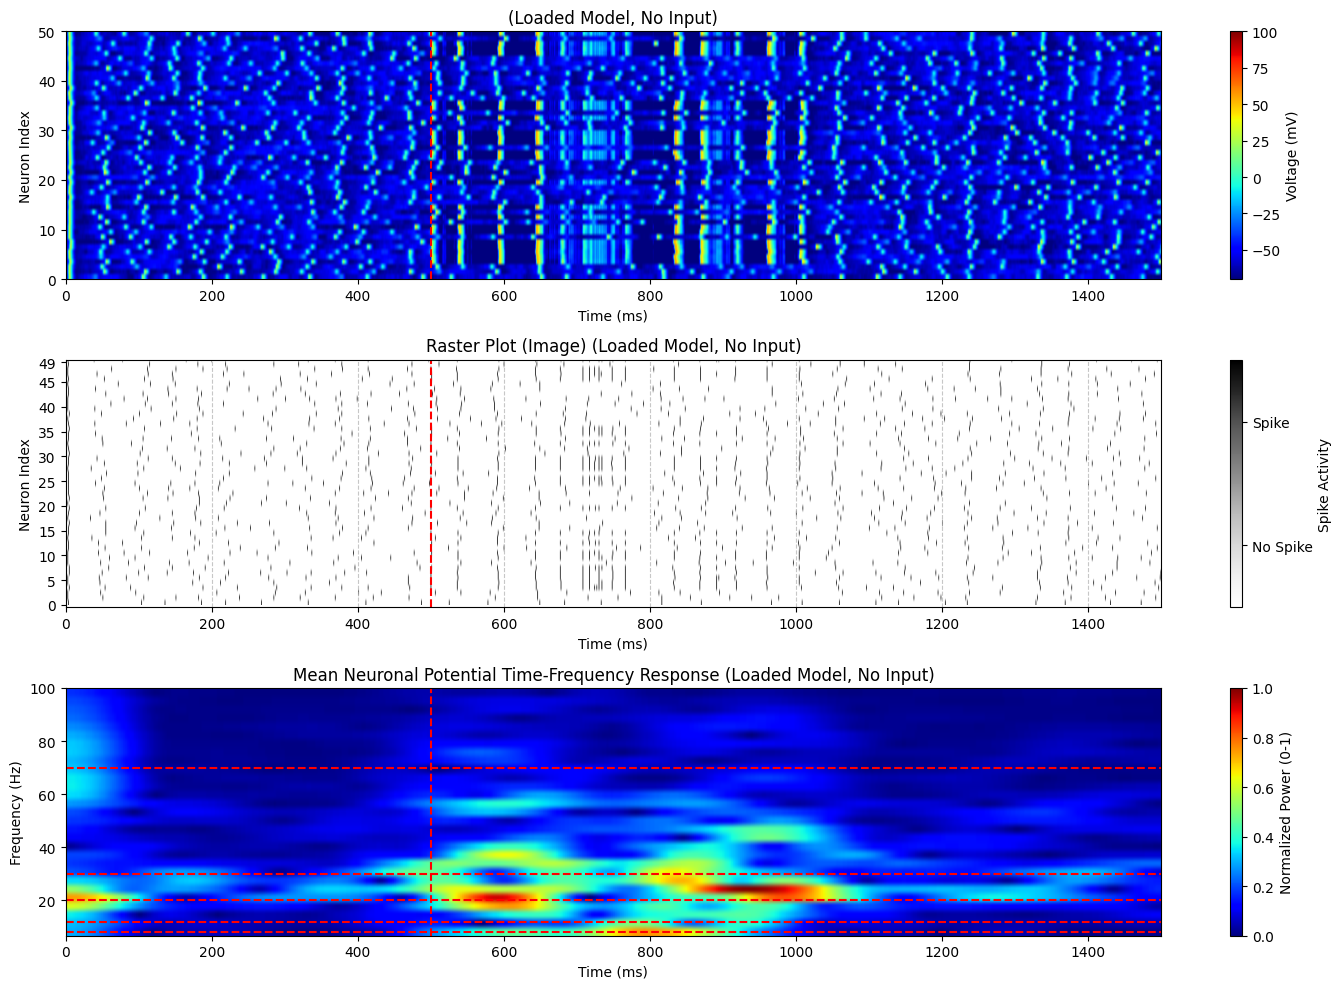

In [ ]:
# loaded_net, loaded_initial_params, loaded_mid_params, loaded_final_params, loaded_log_net = load_jnn("model_000_da", model_save_path)

single_input_amp_no_stim = inputs[3]*1.5
sim_noise_current_pulse_no_stim = noise_current(
    i_delay=500.0,
    i_dur=500.0,
    i_amp=single_input_amp_no_stim,
    delta_t=dt_global,
    t_max=t_max_global
)

loaded_net.delete_stimuli()
loaded_net.delete_recordings()

num_posts_to_select = 22
posts_pool_indices = jnp.concat([jnp.arange(0, Ne), jnp.arange(Ne + Nig, Ne + Nig + Nil)])
key_conn = jax.random.PRNGKey(5678)
selected_post_indices = np.array(jax.random.choice(key_conn, posts_pool_indices, shape=(num_posts_to_select,), replace=False))

data_stimuli_no_stim = loaded_net.cell(selected_post_indices).branch(0).loc(0.0).data_stimulate(sim_noise_current_pulse_no_stim)
loaded_net.cell([i for i in range(Ne+Nig+Nil)]).branch(0).loc(0.0).record()

# loaded_net.GradedAMPA.set("tauDAMPA", 5.0)

print(f"Running post-training simulation with loaded parameters (no input, amp={single_input_amp_no_stim:.2f} nA)...")
recorded_voltages_loaded = jx.integrate(loaded_net, params=loaded_initial_params, data_stimuli=data_stimuli_no_stim, checkpoint_lengths=checkpoints)
print(f"Post-training simulation completed. Recorded voltages shape: {recorded_voltages_loaded.shape}")

time_axis_loaded = jnp.arange(0, t_max_global, dt_global)

plot_full_simulation_summary(recorded_voltages_loaded, time_axis_loaded, dt_global,
                             spike_threshold=-20.0,
                             window_size=300.0, overlap=0.99,
                             f_min=4.0, f_max=100.0,
                             title_suffix="(Loaded Model, No Input)",
                             save=False, save_fname="f_loaded_no_stim.svg")

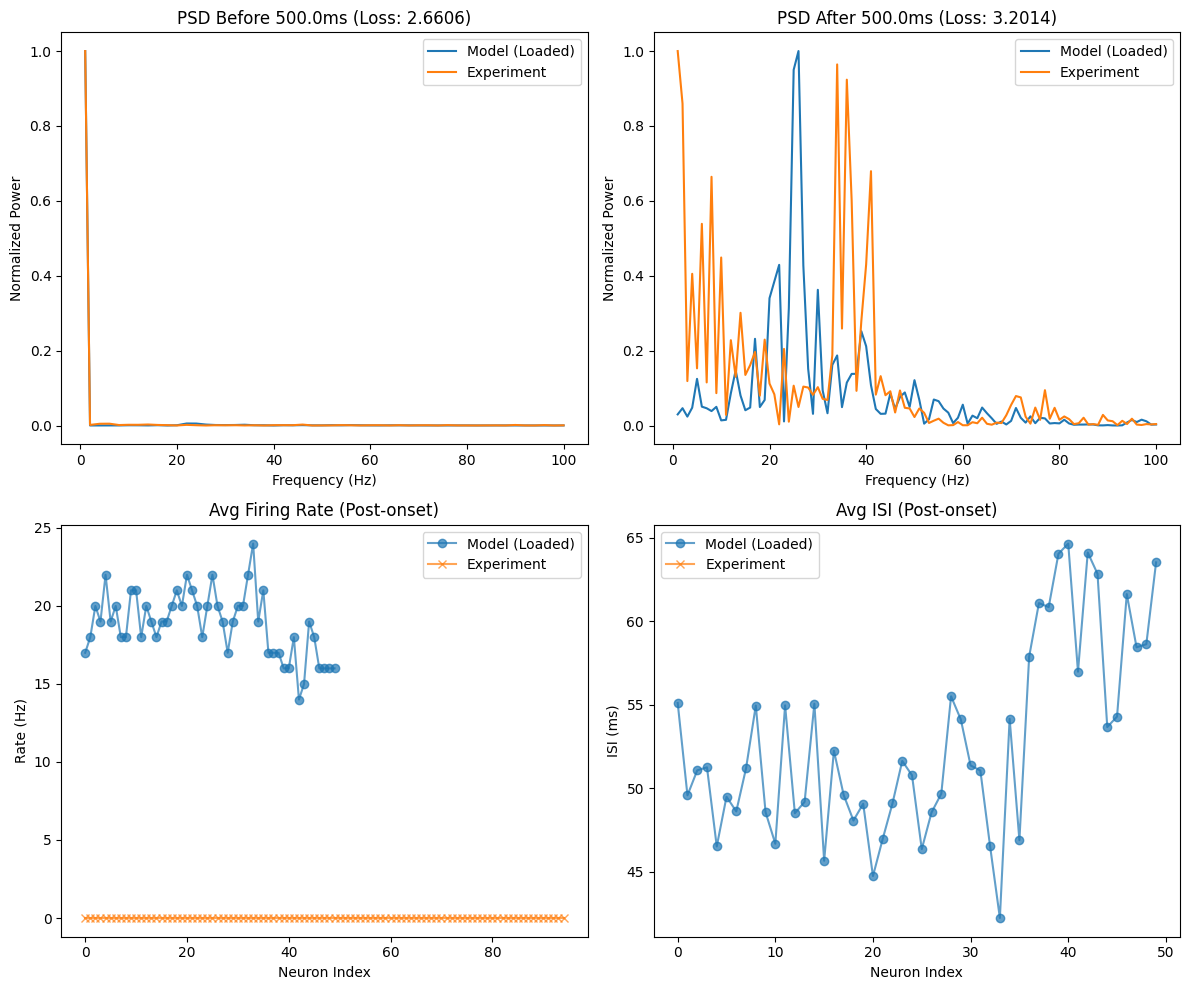

In [ ]:
# Prepare Data for Comparison

# 1. Model Data (from the loaded simulation)
model_voltages = recorded_voltages_loaded
dt_model = dt_global

# 2. Experimental Data
# We take the mean across trials (axis 0) and transpose to (Neurons, Time)
# We slice [:, 500:, :] to get the 1500ms window used in previous visualizations
data_voltages = jnp.mean(selected_unit_spiking[:, 500:, :], axis=0).T
dt_data = 1.0 # Experimental data is 1kHz (1ms dt)

# 3. Plot
plot_simulation_psd(
    recorded_voltages1=model_voltages,
    dt1=dt_model,
    title1="Model (Loaded)",
    recorded_voltages2=data_voltages,
    dt2=dt_data,
    title2="Experiment",
    t_onset=500.0,
    spike_threshold=-20.0
)

In [ ]:
# Load all "model_gsg_a***" models
# Visualize:
# >subplot(4, 1, 1): Loss+- per trial (redline)
# >subplot(4, 1, 2): Correlation to data per trial (LogCor)
# >subplot(4, 1, 3): Relative gamma+-, beta+- and alpha+- per trial
# >>solid line for gamma 35-45Hz, dashed line for broadband gamma 35Hz+
# >>dashed lines for alpha 8-12Hz and beta 12-30Hz
# >subplot(4, 1, 4): Firing rate and ISI per neuron type, model and trial est
# Visualize:
# >subplot(2, 2, 1): initial connectivity (50 in 50) with neurons 1-50 (EX/INg/INl)
# >subplot(2, 2, 2): final connectivity
# >subplot(2, 2, 3): initial MCDP matrix
# >subplot(2, 2, 4): final MCDP matrix

# TODO next: parameter sweep

# TODO after: PGSDR (improve for later)
#   1: Alpha increases/decreases based on checkpoint_n and relative to total loss
# TODO after:

Previous connectivity matrix format

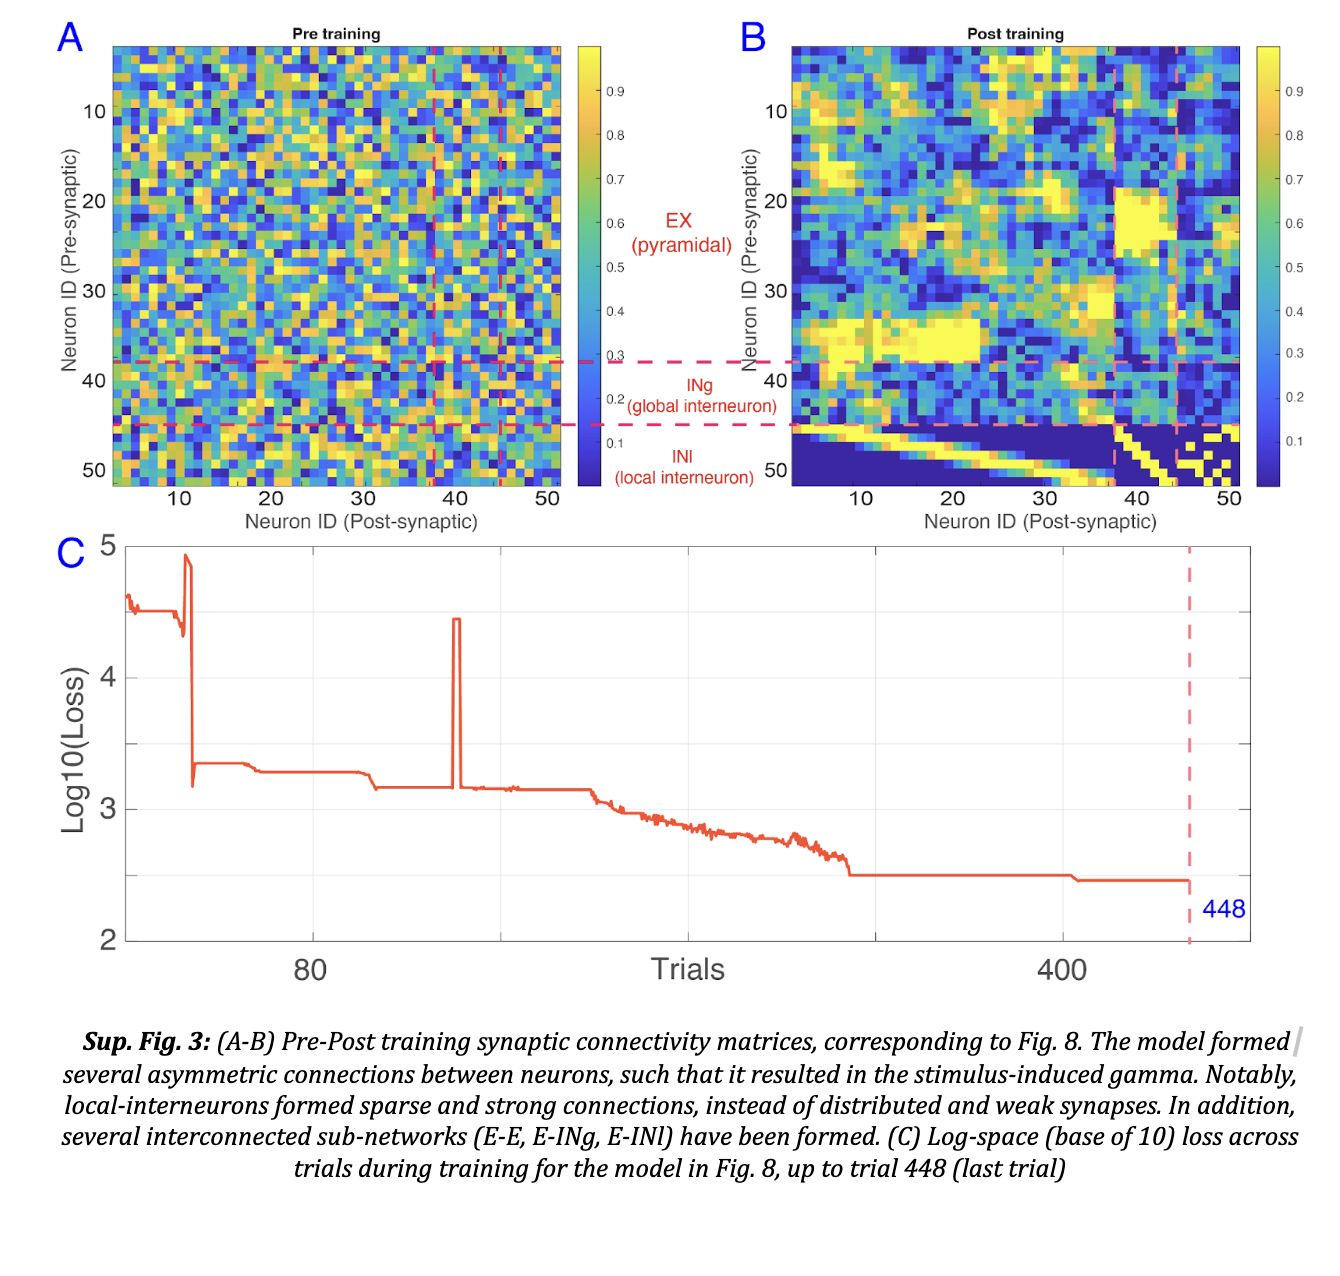

Model components loaded from /content/data/NeuralCircuits/model_000_da.pkl
Added 50 recordings. See `.recordings` for details.
Running post-training simulation with loaded parameters (no input, amp=-1.00 nA)...
Post-training simulation completed. Recorded voltages shape: (50, 15002)


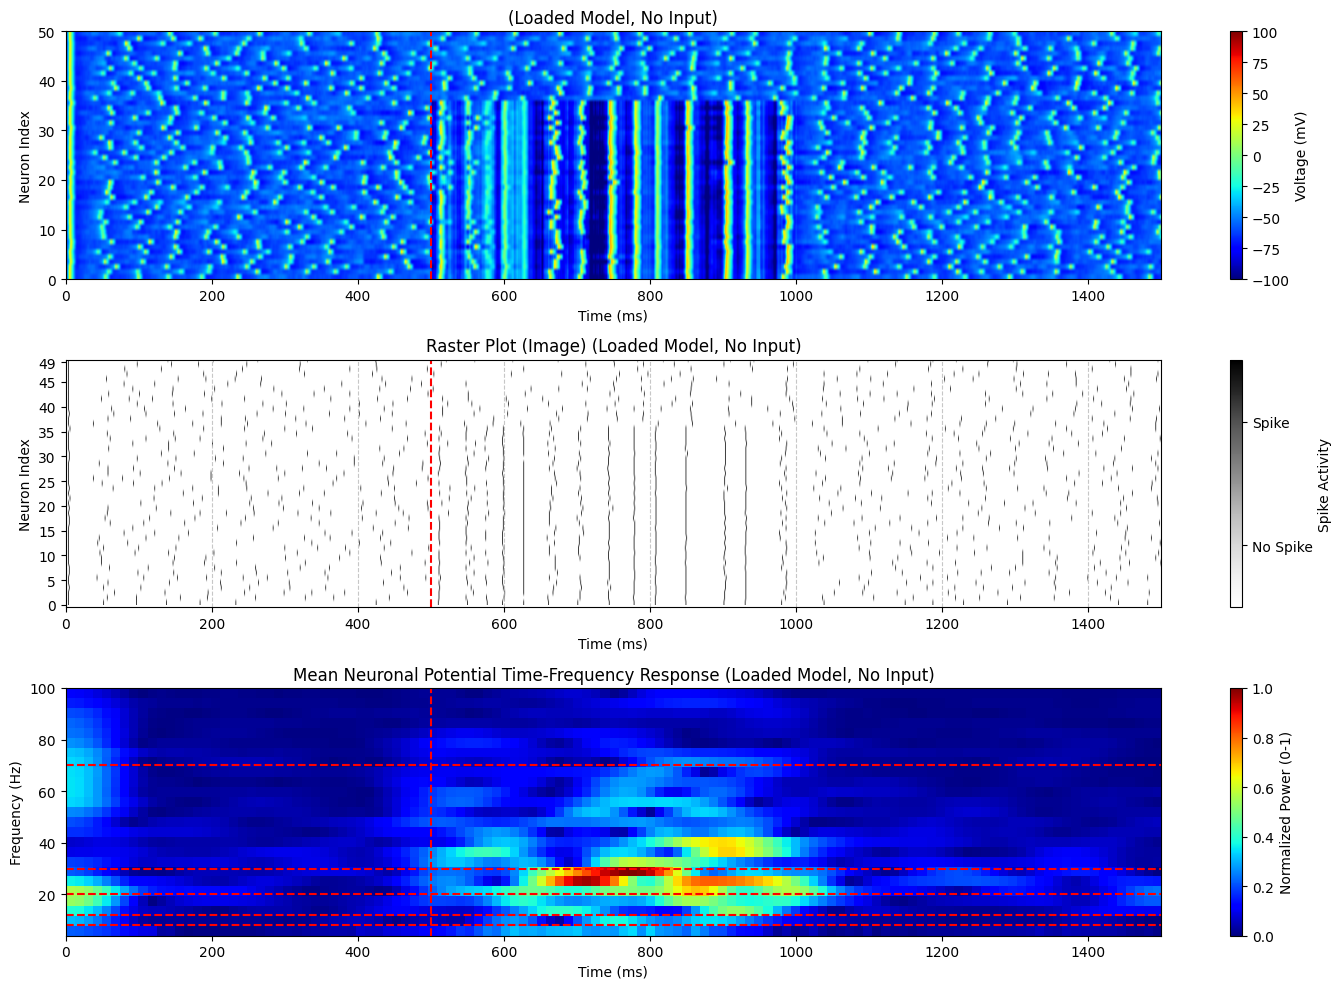

In [ ]:
# import pickle # Import pickle for serialization
# save_jnn(save_model_name, save_model_path, net, initial_params_0, mid_params_0, final_params_0, log_net_0)

loaded_net, loaded_initial_params, loaded_mid_params, loaded_final_params, loaded_log_net = load_jnn("model_000_dynamic", model_save_path)

single_input_amp_no_stim = inputs[3]
sim_noise_current_pulse_no_stim = noise_current(
    i_delay=500.0,
    i_dur=500.0,
    i_amp=single_input_amp_no_stim,
    delta_t=dt_global,
    t_max=t_max_global
)

loaded_net.delete_stimuli()
loaded_net.delete_recordings()
data_stimuli_no_stim = loaded_net.cell([ik for ik in range(Ne)]).branch(0).loc(0.0).data_stimulate(sim_noise_current_pulse_no_stim)
loaded_net.cell([i for i in range(Ne+Nig+Nil)]).branch(0).loc(0.0).record()

print(f"Running post-training simulation with loaded parameters (no input, amp={single_input_amp_no_stim:.2f} nA)...")
recorded_voltages_loaded = jx.integrate(loaded_net, params=loaded_final_params, data_stimuli=data_stimuli_no_stim, checkpoint_lengths=checkpoints)
print(f"Post-training simulation completed. Recorded voltages shape: {recorded_voltages_loaded.shape}")

time_axis_loaded = jnp.arange(0, t_max_global, dt_global)

plot_full_simulation_summary(recorded_voltages_loaded, time_axis_loaded, dt_global,
                             spike_threshold=-20.0,
                             window_size=250.0, overlap=0.95,
                             f_min=1.0, f_max=100.0,
                             title_suffix="(Loaded Model, No Input)",
                             save=False, save_fname="f_loaded_no_stim.svg")

In [40]:
def plot_trajectory_bandpowers(log_nets, save_fname=None, band1=None, band2=None):

    if band1 is None:
        band1 = 'gamma'
    if band2 is None:
        band2 = 'beta'

    fig, axes = plt.subplots(1, 1, figsize=(10, 10))

    for i, log_net in enumerate(log_nets):

        if 'gsdr_alpha' in log_net:
            alph_t = log_net['gsdr_alpha'][0]
            alpha_key = 'gsdr_alpha'
        elif 'alpha' in log_net:
            alph_t = log_net['alpha'][0]
            alpha_key = 'alpha'
        else:
            alph_t = 0.0
            alpha_key = None

        if alpha_key and alph_t != log_net[alpha_key][-1]: # Check if alpha changed
            label = f'Dynamic alpha s{i}'
        else:
            label = f'Static alph-{alph_t}'

        if band1 in log_net and len(log_net[band1]) > 0:

            a_params = jnp.array(log_net[band1])
            b_params = jnp.array(log_net[band2])

            if len(a_params) > 10:
                a_params = ndimage.uniform_filter1d(a_params, 11)
                b_params = ndimage.uniform_filter1d(b_params, 11)

            if a_params[0] != 0:
                a_params = a_params / a_params[0]
            if b_params[0] != 0:
                b_params = b_params / b_params[0]

            # Draw arrows between points
            for j in range(len(a_params) - 1):
                axes.annotate(
                    '', xy=(a_params[j+1], b_params[j+1]), xytext=(a_params[j], b_params[j]),
                    arrowprops=dict(arrowstyle='->', color=plt.cm.viridis(i / len(log_nets)), linewidth=1.5)
                )

            # Mark initial point with 's' for start
            axes.plot(a_params[0], b_params[0], marker='s', markersize=8, color=plt.cm.viridis(i / len(log_nets)), label=None)
            # Mark final point with 'x' for end
            axes.plot(a_params[-1], b_params[-1], marker='x', markersize=8, color=plt.cm.viridis(i / len(log_nets)), label=f'{label} (End)')

    axes.set_title('RelPowChange bands')
    axes.set_xlabel(band1)
    axes.set_ylabel(band2)

    axes.legend(loc='upper right')
    axes.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()

    if save_fname is not None:
        plt.savefig(save_fname, format='svg')

    plt.show()


def plot_trajectory_parameters(log_nets, save_fname=None):

    fig, axes = plt.subplots(1, 1, figsize=(10, 10))

    for i, log_net in enumerate(log_nets):

        # Handle different key names for alpha depending on model version
        if 'gsdr_alpha' in log_net:
            alph_t = log_net['gsdr_alpha'][0]
            alpha_key = 'gsdr_alpha'
        elif 'alpha' in log_net:
            alph_t = log_net['alpha'][0]
            alpha_key = 'alpha'
        else:
            alph_t = 0.0
            alpha_key = None

        if alpha_key and alph_t != log_net[alpha_key][-1]: # Check if alpha changed
            label = f'Dynamic alpha s{i}'
        else:
            label = f'Static Alph-{alph_t}'

        # Ensure we have data to plot
        if 'avg_bounded_params' in log_net and len(log_net['avg_bounded_params']) > 0:
            avg_params = jnp.array(log_net['avg_bounded_params'])
            # Avoid division by zero
            if avg_params[0] != 0:
                avg_params = avg_params / avg_params[0]

            std_params = jnp.array(log_net['std_bounded_params'])

            # Smoothing
            if len(avg_params) > 7:
                avg_params = ndimage.uniform_filter1d(avg_params, 10)
                std_params = ndimage.uniform_filter1d(std_params, 10)

            avg_params = avg_params / avg_params[0] # RelChange
            std_params = std_params / std_params[0] # RelChange
            axes.plot(avg_params, std_params, label=label, linestyle='--', marker='*')

    axes.set_title('Std vs. Avg. Bounded Parameters')
    axes.set_xlabel('Avg. Bounded Parameters (Normalized)')
    axes.set_ylabel('Std. Bounded Parameters')

    axes.legend(loc='upper right')
    axes.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()

    if save_fname is not None:
        plt.savefig(save_fname, format='svg')

    plt.show()


def plot_training_logs(log_nets, save_fname=None):

    fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=True)

    for i, log_net in enumerate(log_nets):

        if 'gsdr_alpha' in log_net:
            alph_t = log_net['gsdr_alpha'][0]
            alpha_key = 'gsdr_alpha'
        elif 'alpha' in log_net:
            alph_t = log_net['alpha'][0]
            alpha_key = 'alpha'
        else:
            alph_t = 0.0
            alpha_key = None

        if alpha_key and len(log_net[alpha_key]) > 10 and alph_t != log_net[alpha_key][10]:
             label = f'Dynamic alpha s{i}'
        else:
             label = f'Static Alph-{alph_t}'

        epochs = jnp.arange(len(log_net['loss']))
        loss_data = jnp.array(log_net['loss'])
        loss_data = jnp.where(jnp.isfinite(loss_data), loss_data, 1e-6) # Replace inf/nan
        loss_t = jnp.log(loss_data)

        smoothing_window = 7

        if len(loss_t) > smoothing_window:
            loss_tm = ndimage.uniform_filter1d(loss_t, size=smoothing_window)
            std_loss_t = ndimage.uniform_filter1d(jnp.abs(loss_t - loss_tm), size=smoothing_window*10)

            axes[0].plot(epochs, loss_tm, label=label)
            axes[0].fill_between(epochs, loss_tm - std_loss_t, loss_tm + std_loss_t, alpha=0.2)
        else:
             axes[0].plot(epochs, loss_t, label=label)

        axes[0].set_title('Log(Loss) per Trial')
        axes[0].set_ylabel('Log Loss')

        # Plot Alpha
        if alpha_key:
            axes[1].plot(epochs, log_net[alpha_key], label=label)

        axes[1].set_title('Alpha per Trial')
        axes[1].set_ylabel('Alpha')
        if len(epochs) > 0:
            axes[1].set_xlim(0, max(epochs))
        axes[1].set_ylim(0, 1.1)


    for ax in axes:
        ax.legend(loc='upper right')
        ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()

    if save_fname is not None:
        plt.savefig(save_fname, format='svg')

    plt.show()


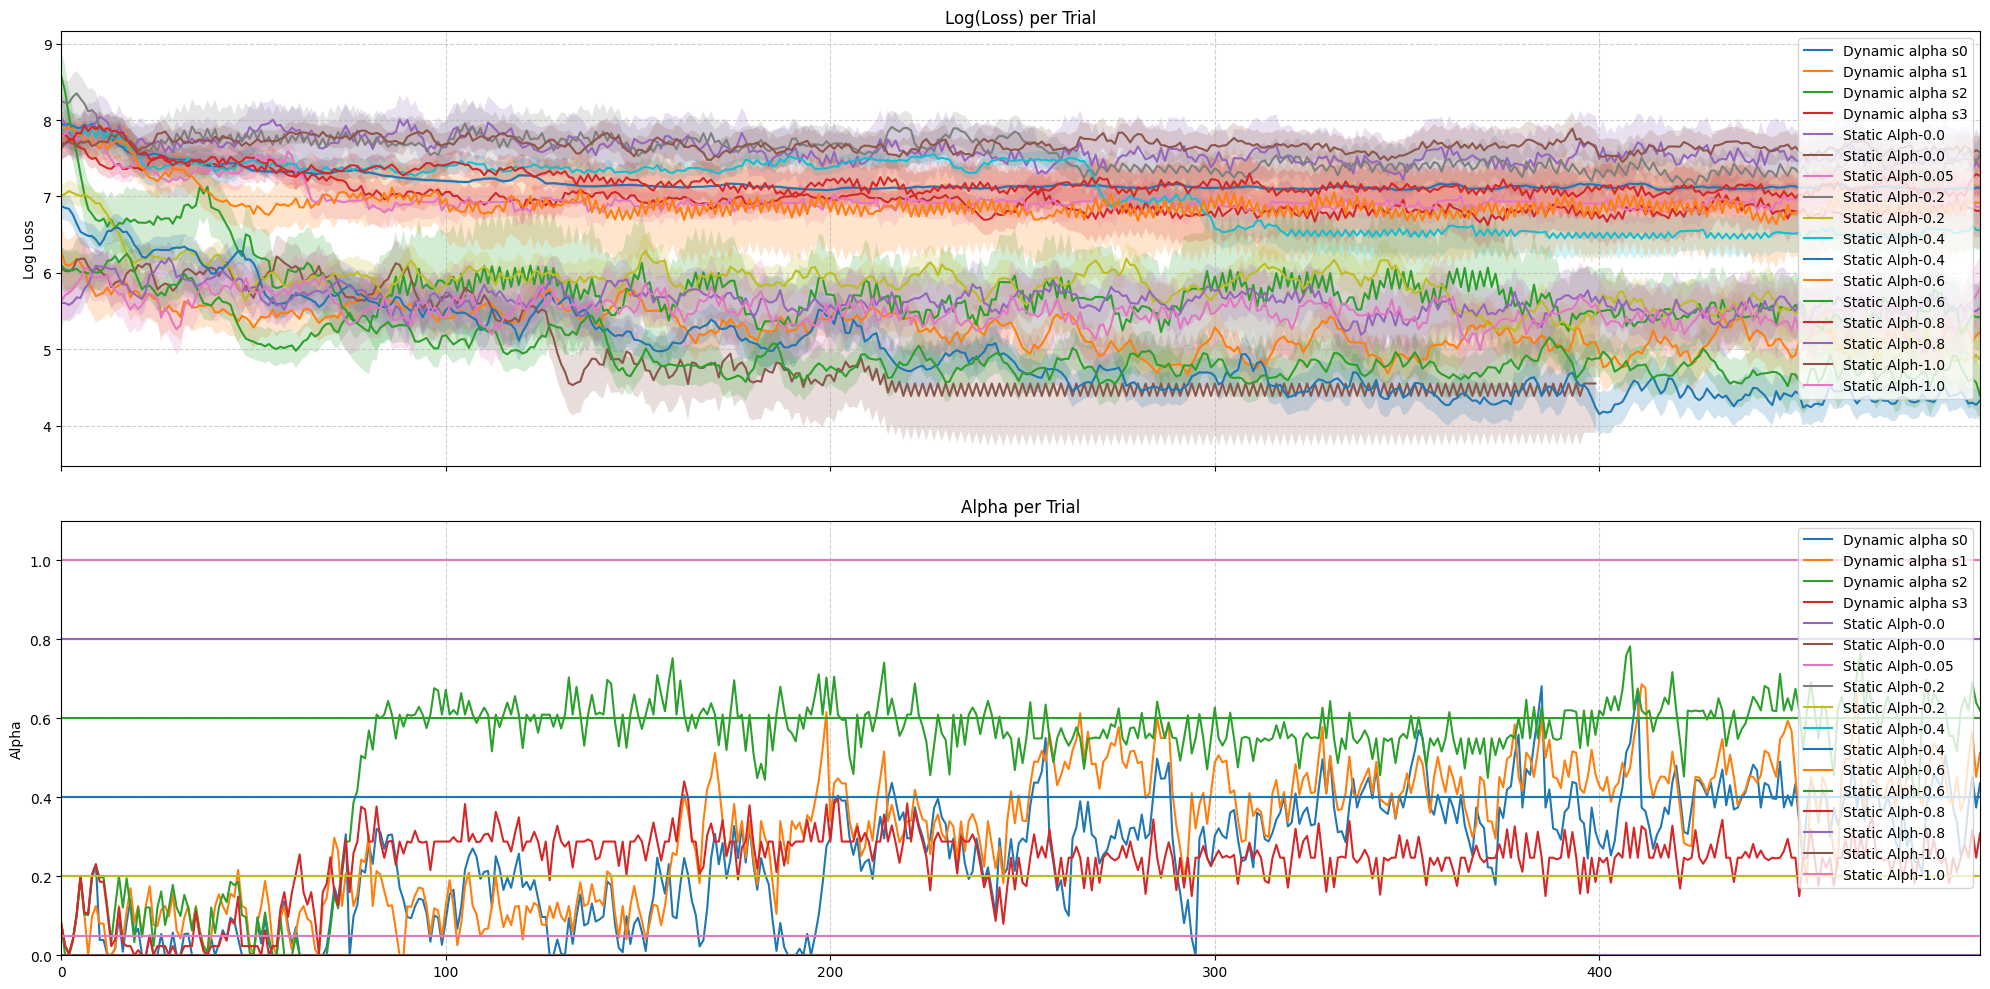

In [41]:
plot_training_logs(loaded_log_nets, "GSDR_alpha_logs_rw.svg")

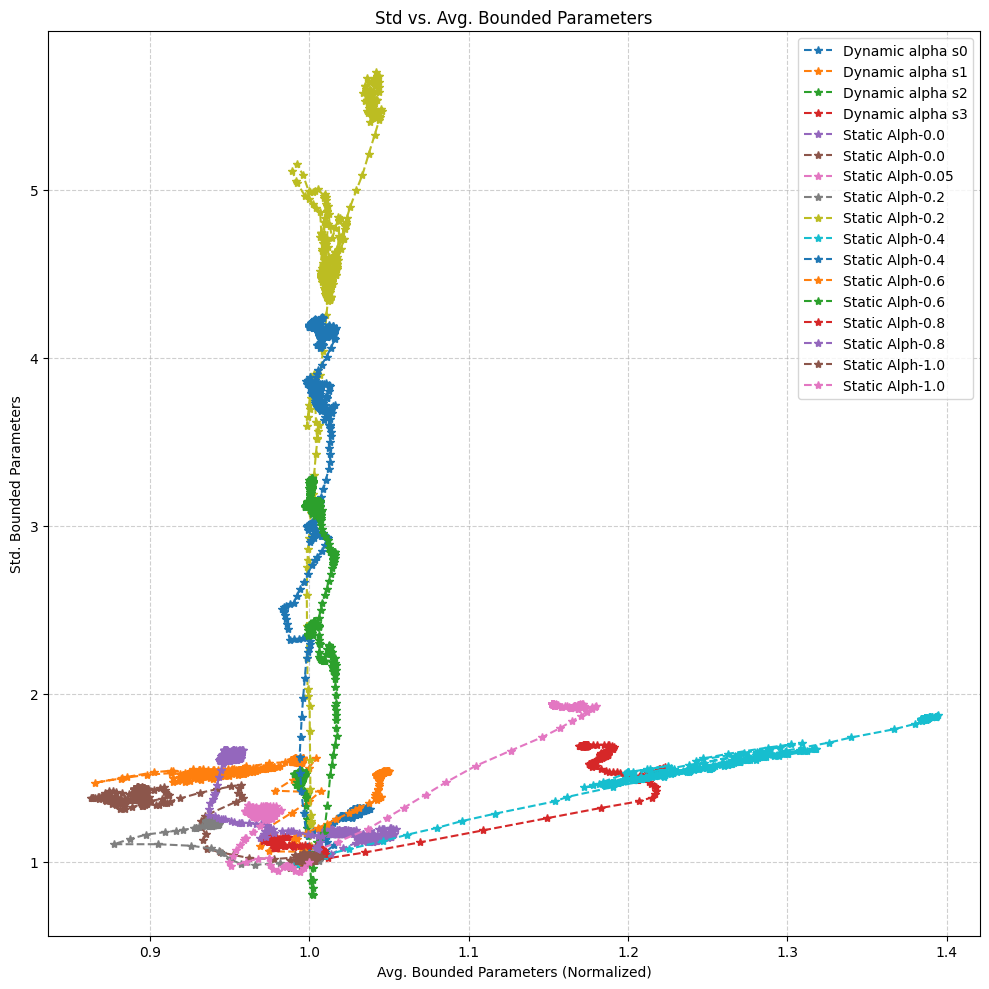

In [38]:
plot_trajectory_parameters(loaded_log_nets, "GSDR_trj_logs_rw.svg")

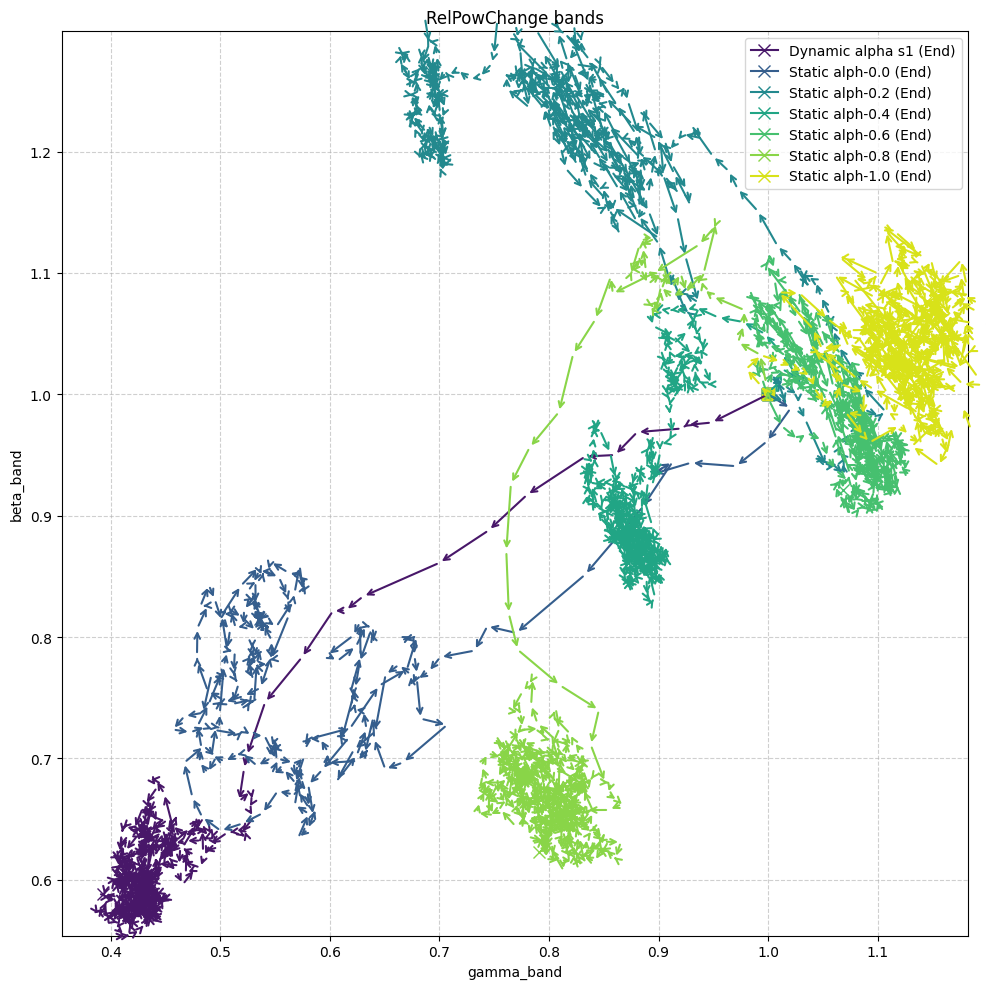

In [39]:
plot_trajectory_bandpowers(loaded_log_nets, "GSDR-trj_logs_bands.svg", "gamma_band", "beta_band")